# Region3 - Primary 386
## Xiaonan Wang
## 22Aug2026

### Setup and paths

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(SeuratObject)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(Matrix)
  library(ggplot2)
})

set.seed(1234)

In [2]:
PROJECT_ROOT <- "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium"
PIPELINE_REPO <- file.path(PROJECT_ROOT, "adipose_analysis", "YNH_Xenium_scWAT")
RUN_LABEL <- "full_notebook_qc_v2"
QC_RUN_ROOT <- file.path(
  PROJECT_ROOT,
  "adipose_analysis",
  "scwat_qc_outputs",
  RUN_LABEL
)
DOWNSTREAM_ROOT <- file.path(
  PROJECT_ROOT,
  "adipose_analysis",
  "scwat_downstream_outputs",
  RUN_LABEL
)
ANCHOR_ROOT <- file.path(
  DOWNSTREAM_ROOT,
  "03_region3_Primary386"
)
INPUT_ROOT <- file.path(PROJECT_ROOT, "adipose_data")

In [83]:
source(file.path(PIPELINE_REPO, "R", "source.R"))

In [4]:
assert_path_within(PROJECT_ROOT, QC_RUN_ROOT)
assert_path_within(PROJECT_ROOT, DOWNSTREAM_ROOT)
dir.create(DOWNSTREAM_ROOT, recursive = TRUE, showWarnings = FALSE)
assert_path_within(PROJECT_ROOT, ANCHOR_ROOT)
dir.create(ANCHOR_ROOT, recursive = TRUE, showWarnings = FALSE)

In [5]:
REGION_ID = "Region_3"

### Create Seurat Obj

In [6]:
region_data <- readRDS(
  file.path(
    PROJECT_ROOT,
    "adipose_analysis",
    "scwat_qc_outputs",
    RUN_LABEL,
    "downstream_inputs",
    paste0(REGION_ID, ".downstream_input.rds")
  )
)

In [7]:
names(region_data)

[1] "schema_version"       "region_id"            "section_status"      
 [4] "counts"               "features"             "cell_metadata"       
 [7] "gene_sets"            "raw_counts_preserved" "downstream_contract" 
[10] "mapping_requirements" "provenance"

In [8]:
colnames(region_data$cell_metadata)

[1] "cell_id"                                  
 [2] "x_centroid"                               
 [3] "y_centroid"                               
 [4] "transcript_counts"                        
 [5] "control_probe_counts"                     
 [6] "genomic_control_counts"                   
 [7] "control_codeword_counts"                  
 [8] "unassigned_codeword_counts"               
 [9] "deprecated_codeword_counts"               
[10] "total_counts"                             
[11] "cell_area"                                
[12] "nucleus_area"                             
[13] "nucleus_count"                            
[14] "segmentation_method"                      
[15] "region_id"                                
[16] "nCount_Xenium"                            
[17] "nFeature_Xenium"                          
[18] "control_fraction_cell"                    
[19] "nucleus_missing_flag"                     
[20] "multiple_nuclei_flag"                     
[21] "cell_area_outlier_flag"                   
[22] "high_control_flag"                        
[23] "segmentation_multiplet_flag"              
[24] "qc_core_pass"                             
[25] "qc_review_flag"                           
[26] "mouse_id"                                 
[27] "section_id"                               
[28] "biological_replicate_id"                  
[29] "genotype"                                 
[30] "treatment"                                
[31] "condition"                                
[32] "age_weeks"                                
[33] "metadata_status"                          
[34] "do_not_interpret"                         
[35] "grid_x"                                   
[36] "grid_y"                                   
[37] "grid_id"                                  
[38] "edge_proxy"                               
[39] "grid_size_um"                             
[40] "local_density"                            
[41] "dense_aggregate"                          
[42] "primary_include"                          
[43] "strict_include"                           
[44] "hotspot_review_cell"                      
[45] "hotspot_sensitivity_include"              
[46] "section_status"                           
[47] "mask_rule_primary"                        
[48] "mask_rule_strict"                         
[49] "mask_rule_hotspot_sensitivity"            
[50] "provenance"                               
[51] "run_label"                                
[52] "execution_mode"                           
[53] "generated_utc"                            
[54] "source_artifact"                          
[55] "section_input_cells"                      
[56] "section_primary_include_cells"            
[57] "section_strict_include_cells"             
[58] "section_hotspot_sensitivity_include_cells"
[59] "qc_threshold_source"

In [9]:
# EOS features
EOS_GENE_SET_PATH <- file.path(
  PIPELINE_REPO,
  "config",
  "eos_gene_sets.tsv"
)

eos_gene_sets <- read.delim(
  EOS_GENE_SET_PATH,
  stringsAsFactors = FALSE
)

In [10]:
# Identity-transfer panel:
# complete 479-gene panel minus short-/long-lived Eos state genes.
# This retains the original 379 mMulti genes plus the 7 common Eos identity genes.

eos_state_genes <- unique(
  eos_gene_sets$gene[
    eos_gene_sets$gene_set %in% c("short_lived", "long_lived")
  ]
)

raw_panel_genes <- region_data$gene_sets$raw_complete_panel

identity_panel_genes <- setdiff(
  raw_panel_genes,
  eos_state_genes
)

cat("Raw panel genes:", length(raw_panel_genes), "\n")
cat("Eos state genes excluded:", length(intersect(raw_panel_genes, eos_state_genes)), "\n")
cat("Identity panel genes:", length(identity_panel_genes), "\n")

stopifnot(length(raw_panel_genes) == 479L)


Raw panel genes: 479 
Eos state genes excluded: 93 
Identity panel genes: 386 


In [11]:
FIX_GENESET = identity_panel_genes

In [12]:
region_info <- discover_one_section(
  input_root = INPUT_ROOT,
  region_id = REGION_ID
)
REGION_XENIUM_DIR <- region_info$region_dir

In [13]:
region_info

region_id,region_number,region_dir
<chr>,<int>,<chr>
Region_3,3,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_3__20260805__124712


In [14]:
list.files(
  REGION_XENIUM_DIR,
  recursive = FALSE
)

[1] "analysis"                     "analysis_summary.html"       
 [3] "analysis.zarr.zip"            "aux_outputs"                 
 [5] "cell_boundaries.csv.gz"       "cell_boundaries.parquet"     
 [7] "cell_feature_matrix"          "cell_feature_matrix.h5"      
 [9] "cell_feature_matrix.zarr.zip" "cells.csv.gz"                
[11] "cells.parquet"                "cells.zarr.zip"              
[13] "experiment.xenium"            "gene_panel.json"             
[15] "metrics_summary.csv"          "morphology_focus"            
[17] "morphology.ome.tif"           "nucleus_boundaries.csv.gz"   
[19] "nucleus_boundaries.parquet"   "transcripts.parquet"         
[21] "transcripts.zarr.zip"

In [15]:
region_spatial <- region_bundle_to_spatial_seurat(
  region_data = region_data,
  xenium_dir = REGION_XENIUM_DIR,
  mask = NULL,
  genes = "raw_complete_panel",
  project = "Region_3",
  assay = "Xenium",
  fov = "fov",
  include_cell_segmentation = TRUE,
  include_nucleus_segmentation = TRUE
)

Creating compact cell segmentation from 1,896,500 vertices across 75,957 cells.

Creating compact nucleus segmentation from 1,854,684 vertices across 74,284 cells.

Created spatial Seurat object: Region_3

  Cells: 75,957

  Genes: 479

  FOV: fov

  Boundaries: centroids, segmentation, nucleus_segmentation

  Native Xenium segmentations loaded: segmentation, nucleus_segmentation



In [16]:
region_spatial <- subset(
  region_spatial,
  subset = primary_include == TRUE
)

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


In [17]:
region_spatial

An object of class Seurat 
479 features across 74364 samples within 1 assay 
Active assay: Xenium (479 features, 0 variable features)
 1 layer present: counts
 1 spatial field of view present: fov

In [18]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial.rds")))

In [19]:
# Normalisation - better use lognormlize rather than SCTransform
DefaultAssay(region_spatial) <- "Xenium"

region_spatial <- NormalizeData(
  region_spatial,
  assay = "Xenium",
  normalization.method = "LogNormalize",
  scale.factor = 10000,
  verbose = FALSE
)

In [20]:
region_spatial

An object of class Seurat 
479 features across 74364 samples within 1 assay 
Active assay: Xenium (479 features, 0 variable features)
 2 layers present: counts, data
 1 spatial field of view present: fov

In [21]:
# only use the cell type genes for PCA as key features
region_spatial <- ScaleData(
  region_spatial,
  assay = "Xenium",
  features = FIX_GENESET,
  verbose = FALSE
)

region_spatial <- RunPCA(
  region_spatial,
  assay = "Xenium",
  features = FIX_GENESET,
  npcs = 30,
  seed.use = 1234,
  verbose = FALSE
)

In [22]:
region_spatial

An object of class Seurat 
479 features across 74364 samples within 1 assay 
Active assay: Xenium (479 features, 0 variable features)
 3 layers present: counts, data, scale.data
 1 dimensional reduction calculated: pca
 1 spatial field of view present: fov

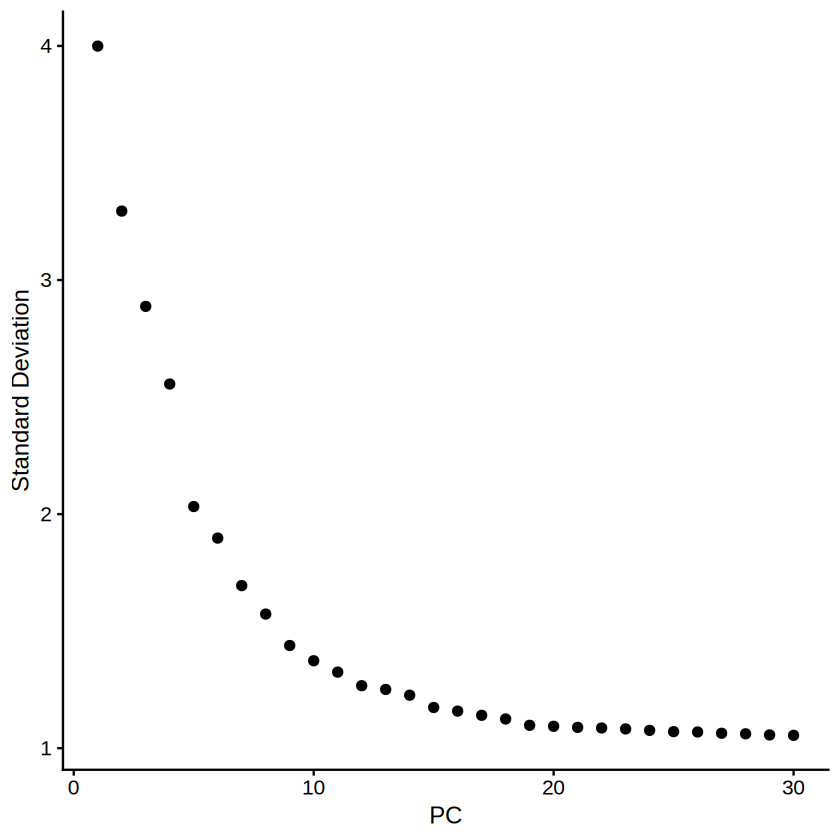

In [23]:
ElbowPlot(
  region_spatial,
  ndims = 30
)

In [24]:
options(repr.plot.width=12, repr.plot.height=12)

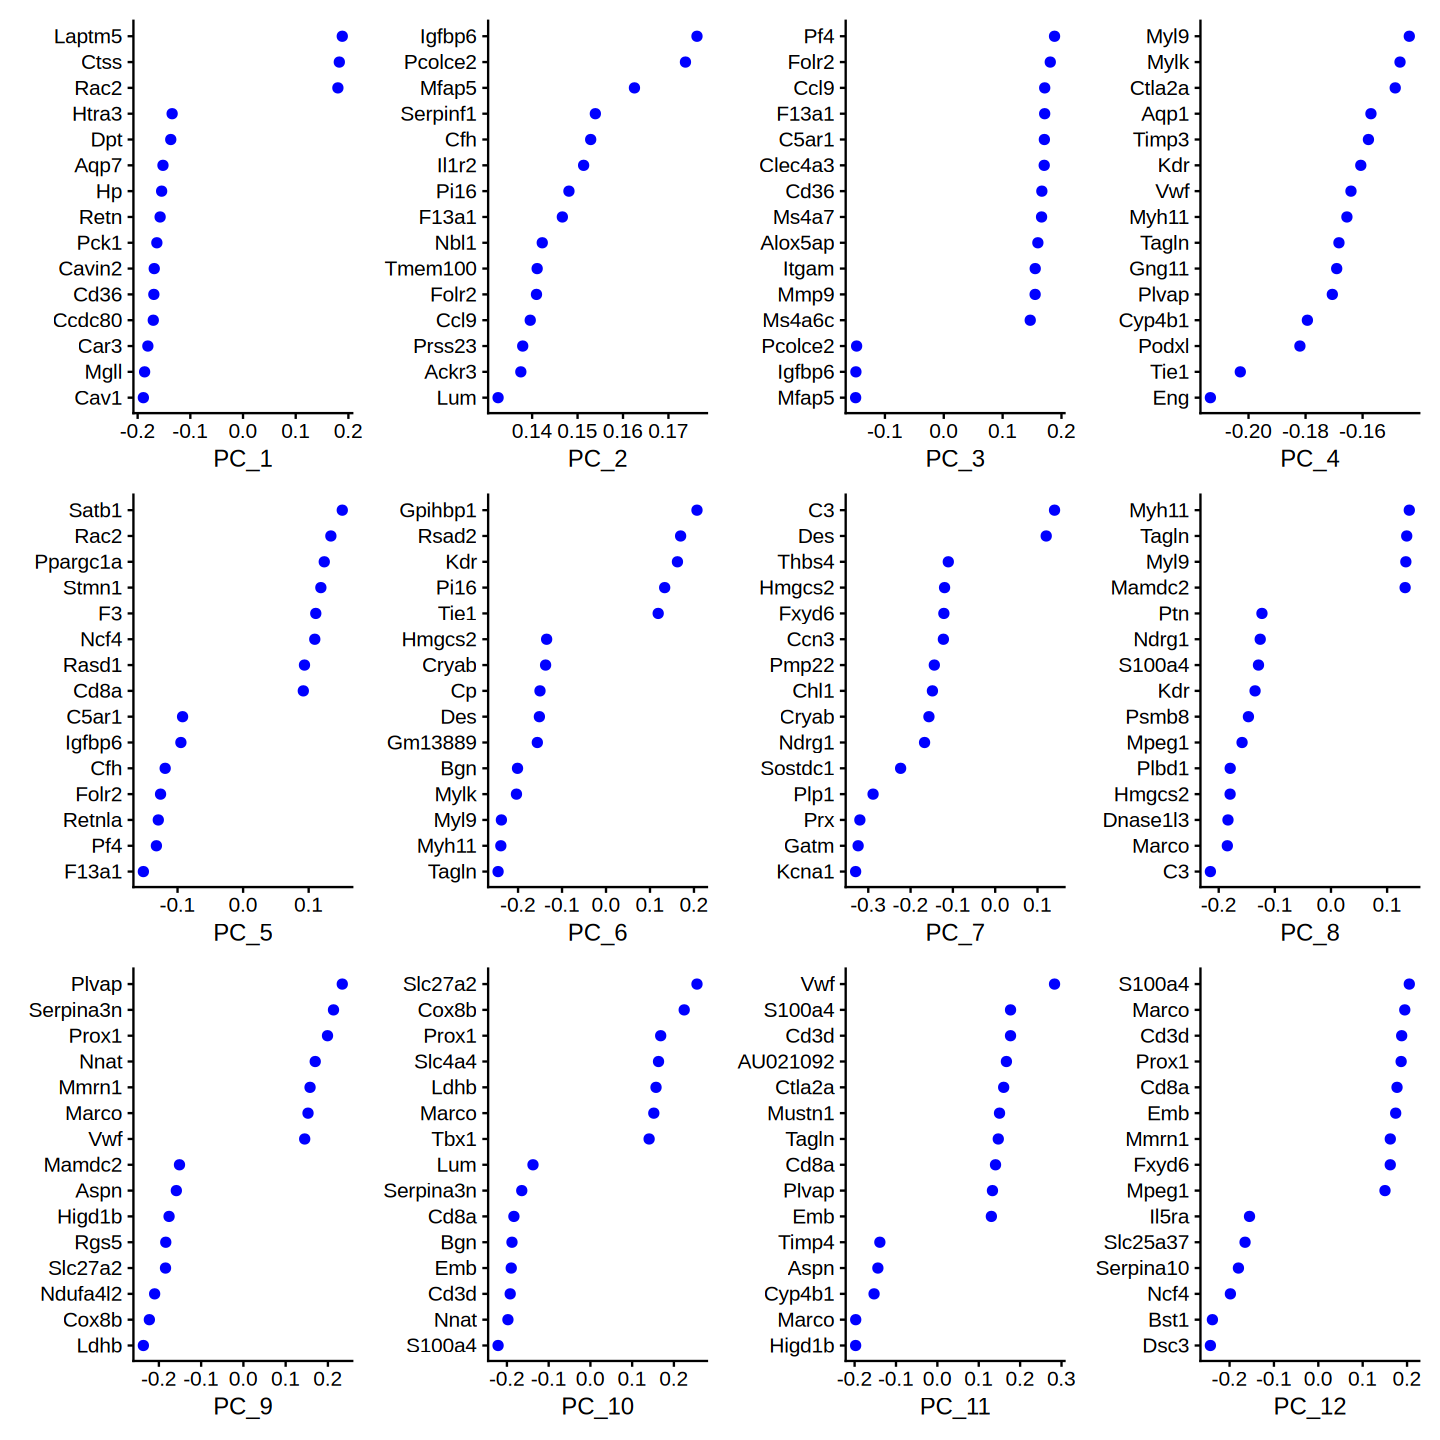

In [25]:
VizDimLoadings(
  region_spatial,
  dims = 1:12,
  reduction = "pca",
  nfeatures = 15
)

- PC1: Laptm5, Ctss, Rac2 versus Dpt, Aqp7, Retn, Cavin2, Cd36, Cav1 — broadly immune versus adipose/stromal structure.
- PC3: Mfap5, Igfbp6, Pcolce2 versus Itgam, Alox5ap, Ms4a7, C5ar1, Folr2, Pf4 — stromal versus myeloid.
- PC4: Eng, Tie1, Podxl, Plvap, Gng11, Kdr with Tagln, Myh11, Myl9 — vascular/endothelial–mural structure.
- PC5: lymphoid/immune genes such as Satb1, Rac2, Cd8a contrasted with macrophage-associated C5ar1, Folr2, Retnla, Pf4.
- PC6/8: very clearly vascular/mural structure, with Kdr, Tie1, Gpihbp1 versus Myh11, Tagln, Myl9.
- PC7: contains Plp1, Prx, Kcna1, which may indicate a peripheral nerve/Schwann-like axis; this will be worth checking spatially.
- PC9/10: appear to represent additional endothelial/lymphatic/immune-stromal distinctions.

In [26]:
pcs <- Embeddings(
  region_spatial,
  reduction = "pca"
)

qc_vars <- c(
  "nCount_Xenium",
  "nFeature_Xenium",
  "cell_area"
)

qc_vars <- qc_vars[
  qc_vars %in% colnames(region_spatial@meta.data)
]

In [27]:
pc_qc_cor <- sapply(
  qc_vars,
  function(v) {
    apply(
      pcs,
      2,
      function(pc) {
        cor(
          pc,
          region_spatial@meta.data[[v]],
          method = "spearman",
          use = "pairwise.complete.obs"
        )
      }
    )
  }
)

round(pc_qc_cor, 3)

,nCount_Xenium,nFeature_Xenium,cell_area
PC_1,-0.241,-0.401,-0.615
PC_2,0.412,0.573,0.123
PC_3,0.258,0.335,0.383
PC_4,-0.024,-0.191,0.242
PC_5,0.330,0.327,0.015
PC_6,-0.053,0.002,-0.167
PC_7,0.360,0.286,0.147
PC_8,-0.320,-0.247,-0.196
PC_9,-0.094,-0.105,-0.035
PC_10,-0.061,-0.073,0.014


PC2 could reflect nCount/nFeature, but may be biologically relevant

In [28]:
dims_use <- 1:12

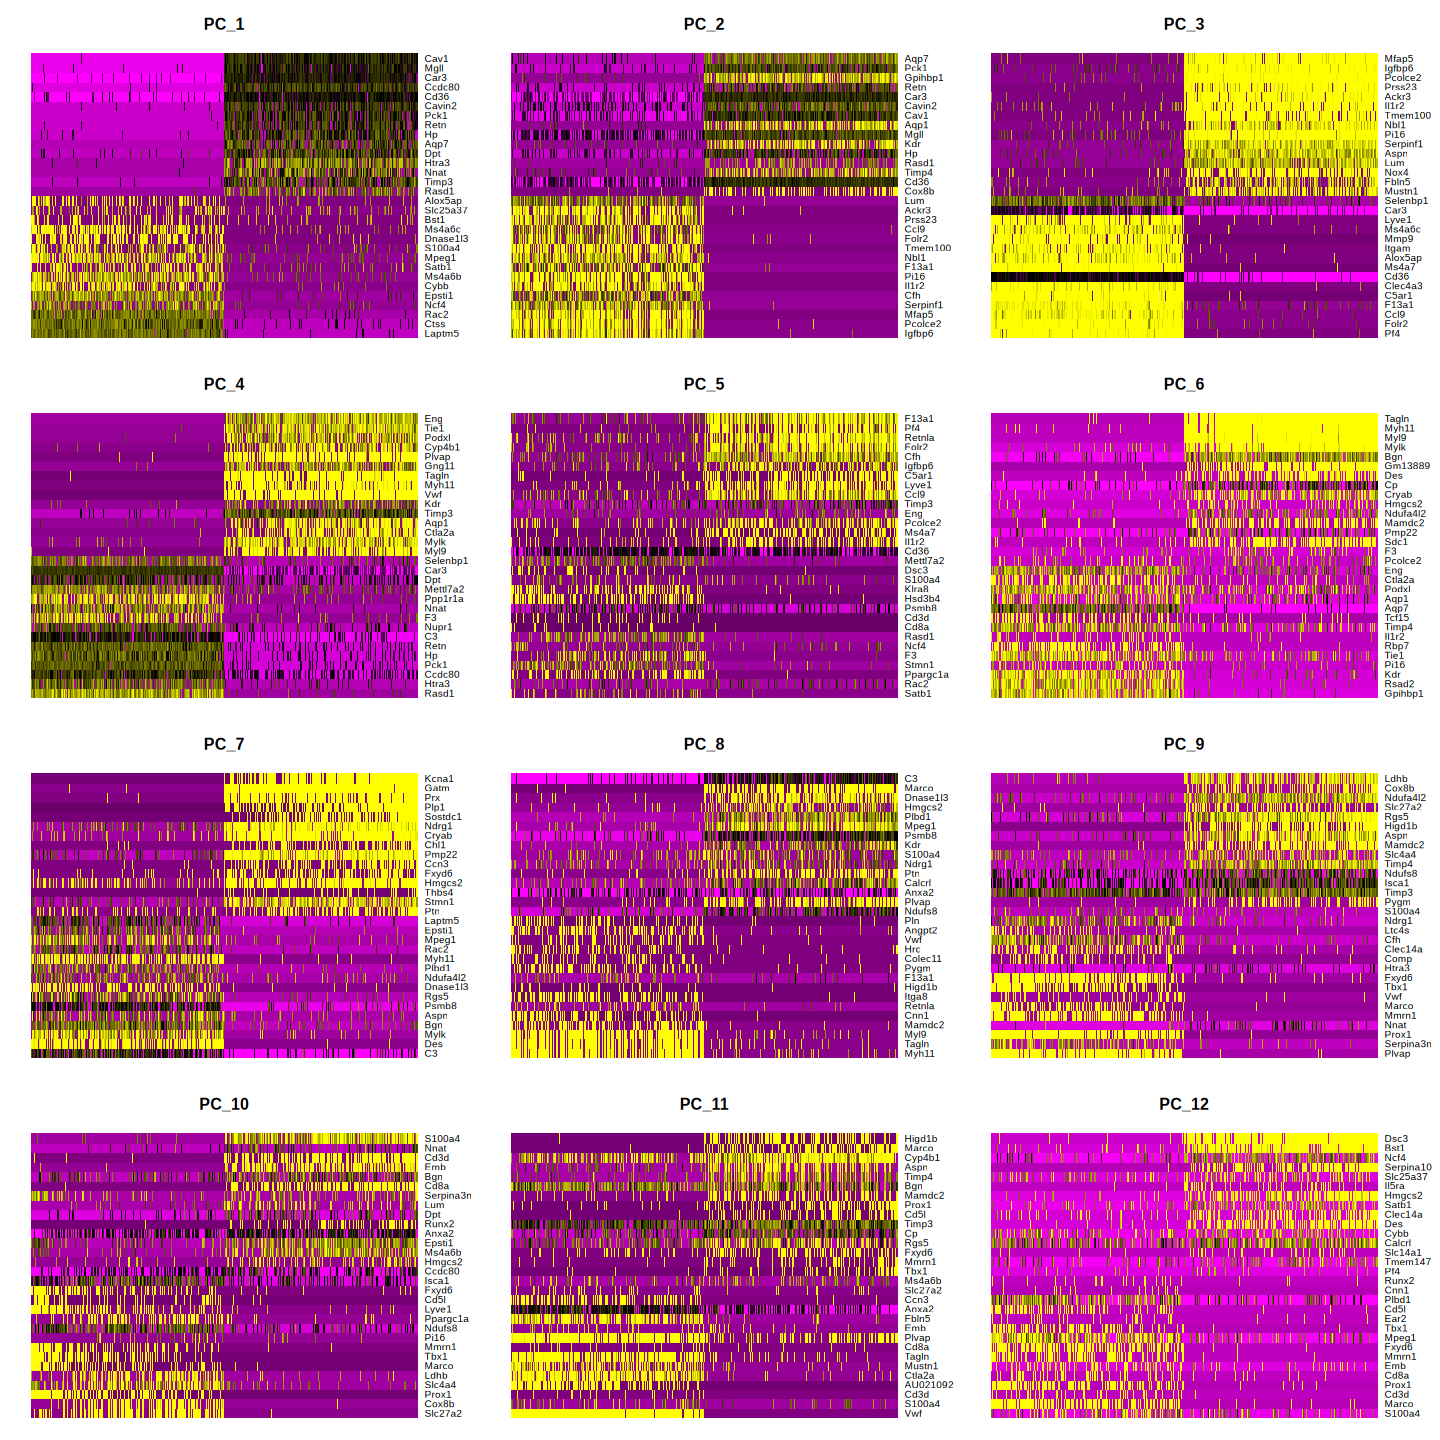

In [29]:
DimHeatmap(
  region_spatial,
  dims = 1:12,
  cells = 1000,
  balanced = TRUE
)

PC1–PC12 are carrying structured, coherent biological programs rather than diffuse noise!

In [30]:
region_spatial <- FindNeighbors(
  region_spatial,
  reduction = "pca",
  dims = dims_use,
  k.param = 20,
  graph.name = c(
    "Xenium_nn_PC12",
    "Xenium_snn_PC12"
  ),
  verbose = FALSE
)

In [31]:
region_spatial <- RunUMAP(
  region_spatial,
  reduction = "pca",
  dims = dims_use,
  reduction.name = "umap_PC12",
  seed.use = 1234,
  verbose = FALSE
)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


In [32]:
resolutions <- c(
  0.7,
  0.8,
  1.0,
  1.2
)

for (res in resolutions) {
  print(res)
  region_spatial <- FindClusters(
    region_spatial,
    graph.name = "Xenium_snn_PC12",
    algorithm = 4,
    resolution = res,
    cluster.name = paste0(
      "cluster_res_",
      gsub("\\.", "_", res)
    ),
    random.seed = 1234,
    verbose = FALSE
  )
}

[1] 0.7
[1] 0.8
[1] 1
[1] 1.2


In [33]:
options(repr.plot.width=12, repr.plot.height=8)

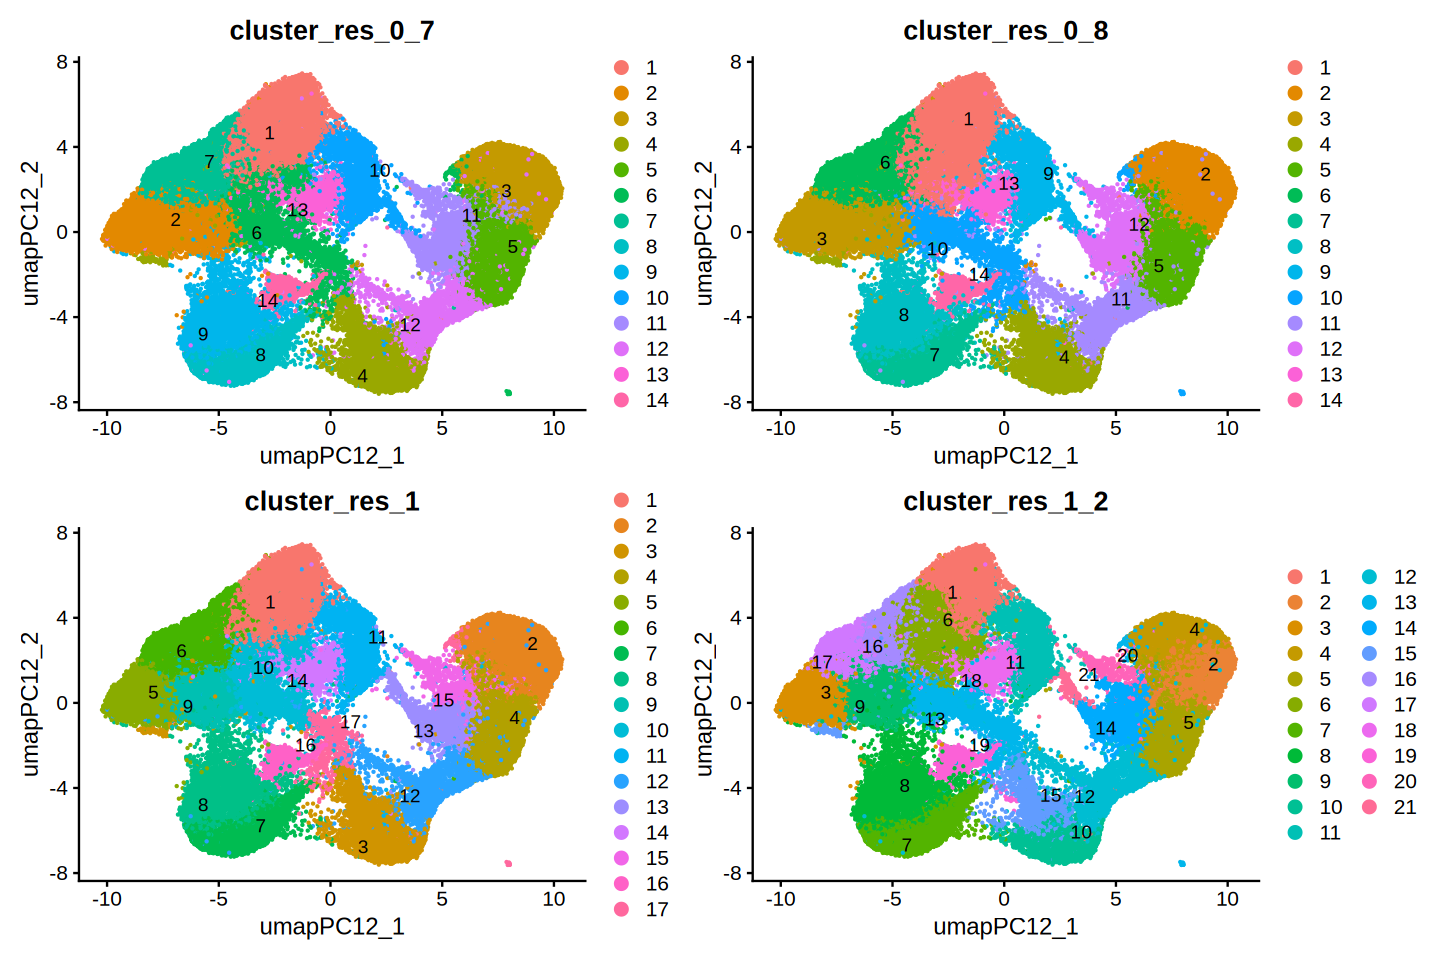

In [34]:
DimPlot(
  region_spatial,
  reduction = "umap_PC12",
  group.by = c(
    "cluster_res_0_7",
    "cluster_res_0_8",
    "cluster_res_1",
    "cluster_res_1_2"
  ),
  label = TRUE,
  repel = TRUE,
  ncol = 2
)

In [35]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial.rds")))

### Cell Type Annotataion M1 - By clustering scores

Try resolution 1.2

In [36]:
region_spatial = readRDS(file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial.rds")))

In [37]:
marker_df <- tibble::tribble(
  ~Gene_Symbol, ~CellType_main, ~CellType_subtype,

  "Gpihbp1", "Endothelial", "Capillary_EC",
  "Kdr",     "Endothelial", "Capillary_EC",

  "Vwf",     "Endothelial", "Venous_EC",
  "Plvap",   "Endothelial", "Venous_EC",

  "Mmrn1",   "Endothelial", "Lymphatic_EC",
  "Prox1",   "Endothelial", "Lymphatic_EC",
  "Lyve1",   "Endothelial", "Lymphatic_EC",

  "Pck1",    "Adipocyte", "Adipocyte",
  "Retn",    "Adipocyte", "Adipocyte",
  "Aqp7",    "Adipocyte", "Adipocyte",
  "Ppargc1a","Adipocyte", "Adipocyte",
  "Car3",    "Adipocyte", "Adipocyte",
  "Cd36",    "Adipocyte", "Adipocyte",

  "Pi16",    "Stromal_Fibroblast", "ASC",
  "Pcolce2", "Stromal_Fibroblast", "ASC",
  "Mfap5",   "Stromal_Fibroblast", "ASC",

  "Lum",     "Stromal_Fibroblast", "Fibroblast",
  "Serpinf1","Stromal_Fibroblast", "Fibroblast",
  "Bgn",     "Stromal_Fibroblast", "Fibroblast",
  "Dpt",     "Stromal_Fibroblast", "Fibroblast",
  "Aspn",    "Stromal_Fibroblast", "Fibroblast",
  "Ccdc80",  "Stromal_Fibroblast", "Fibroblast",

  "Tagln",   "Mural", "VSMC",
  "Myh11",   "Mural", "VSMC",
  "Cnn1",    "Mural", "VSMC",
  "Itga8",   "Mural", "VSMC",
  "Myl9",    "Mural", "VSMC",
  "Mylk",    "Mural", "VSMC",

  "Rgs5",    "Mural", "Pericyte",
  "Higd1b",  "Mural", "Pericyte",
  "Ndufa4l2","Mural", "Pericyte",
  "Myl9",    "Mural", "Pericyte",
  "Des",     "Mural", "Pericyte",
  "Timp3",   "Mural", "Pericyte",

  "Plp1",    "Neural", "Schwann",
  "Prx",     "Neural", "Schwann",
  "Pmp22",   "Neural", "Schwann",
  "Kcna1",   "Neural", "Schwann",
  "Chl1",    "Neural", "Schwann",

  "Pf4",     "Macrophage", "LYVE_macrophage",
  "Folr2",   "Macrophage", "LYVE_macrophage",
  "F13a1",   "Macrophage", "LYVE_macrophage",
  "C5ar1",   "Macrophage", "LYVE_macrophage",
  "Adgre1",  "Macrophage", "LYVE_macrophage",
  "Retnla",  "Macrophage", "LYVE_macrophage",
  "Lyve1",   "Macrophage", "LYVE_macrophage",
  "Ms4a7",   "Macrophage", "LYVE_macrophage",
  "Ccl6",    "Macrophage", "LYVE_macrophage",

  "Marco",   "Macrophage", "Scavenging_macrophage",
  "Mpeg1",   "Macrophage", "Scavenging_macrophage",
  "Cd5l",    "Macrophage", "Scavenging_macrophage",
  "Ms4a6c",  "Macrophage", "Scavenging_macrophage",
  "Lst1",    "Macrophage", "Scavenging_macrophage",

  "Cebpb",   "Monocyte", "Monocyte",
  "Ctss",    "Monocyte", "Monocyte",
  "Cd300a",  "Monocyte", "Monocyte",
  "Cybb",    "Monocyte", "Monocyte",

  "Csf3r",   "Neutrophil", "Neutrophil",
  "Cxcr2",   "Neutrophil", "Neutrophil",
  "Mmp9",    "Neutrophil", "Neutrophil",
  "Ctsg",    "Neutrophil", "Neutrophil",

  "Mrgpra2a",    "Mast cell", "MC",
  "Il1rl1",  "Mast cell", "MC",
  "Stfa2l1",  "Mast cell", "MC",
  "Cstdc4",  "Mast cell", "MC",
  "Asprv1",  "Mast cell", "MC",

  "Alox15",  "Eosinophil", "Eosinophil",
  "Siglecf", "Eosinophil", "Eosinophil",
  "Ccr3",    "Eosinophil", "Eosinophil",
  "Il5ra",   "Eosinophil", "Eosinophil",
  "Prg2",    "Eosinophil", "Eosinophil",
  "Ear1",    "Eosinophil", "Eosinophil",
  "Ear2",    "Eosinophil", "Eosinophil",

  "Cd3d",    "T cell", "T cell",
  "Cd8a",    "T cell", "T cell",
  "Ctla4",   "T cell", "T cell",
  "Epsti1",  "T cell", "T cell",

  "Itgal",   "NK", "NK",
  "Klra8",   "NK", "NK",

  "Basp1",   "DC", "DC",
  "Cytip",   "DC", "DC",
  "Adam8",   "DC", "DC",
  "Rab8b",   "DC", "DC",
  "Runx2",   "DC", "DC",

  "Plbd1",   "DC", "cDC",
  "Cd24a",   "DC", "cDC",
  "Psmb8",   "DC", "cDC",

    # leave B out as they are not good canonical markers 
  # "Slc25a37", "B cell", "B cell",
  # "Slc4a1", "B cell", "B cell",
  # "Cpa3", "B cell", "B cell",
 
  "Krt19",   "Mesothelial", "Mesothelial",
  "Cav1",    "Mesothelial", "Mesothelial",
  "Igfbp6",  "Mesothelial", "Mesothelial"
)
    
marker_df_use <- marker_df %>%
  filter(Gene_Symbol %in% rownames(region_spatial)) %>%
  distinct(Gene_Symbol, CellType_main, CellType_subtype)

In [38]:
table(marker_df_use$CellType_main)


         Adipocyte                 DC        Endothelial         Eosinophil 
                 6                  8                  7                  7 
        Macrophage          Mast cell        Mesothelial           Monocyte 
                14                  5                  3                  4 
             Mural             Neural         Neutrophil                 NK 
                12                  5                  4                  2 
Stromal_Fibroblast             T cell 
                 9                  4 

In [39]:
marker_coverage <- marker_df %>%
  mutate(Present = Gene_Symbol %in% rownames(region_spatial)) %>%
  group_by(CellType_main, CellType_subtype) %>%
  summarise(
    n_markers = n(),
    n_present = sum(Present),
    coverage = n_present / n_markers,
    genes_present = paste(Gene_Symbol[Present], collapse = ", "),
    .groups = "drop"
  ) %>%
  arrange(CellType_main, CellType_subtype)

marker_coverage

CellType_main,CellType_subtype,n_markers,n_present,coverage,genes_present
<chr>,<chr>,<int>,<int>,<dbl>,<chr>
Adipocyte,Adipocyte,6,6,1,"Pck1, Retn, Aqp7, Ppargc1a, Car3, Cd36"
DC,DC,5,5,1,"Basp1, Cytip, Adam8, Rab8b, Runx2"
DC,cDC,3,3,1,"Plbd1, Cd24a, Psmb8"
Endothelial,Capillary_EC,2,2,1,"Gpihbp1, Kdr"
Endothelial,Lymphatic_EC,3,3,1,"Mmrn1, Prox1, Lyve1"
Endothelial,Venous_EC,2,2,1,"Vwf, Plvap"
Eosinophil,Eosinophil,7,7,1,"Alox15, Siglecf, Ccr3, Il5ra, Prg2, Ear1, Ear2"
Macrophage,LYVE_macrophage,9,9,1,"Pf4, Folr2, F13a1, C5ar1, Adgre1, Retnla, Lyve1, Ms4a7, Ccl6"
Macrophage,Scavenging_macrophage,5,5,1,"Marco, Mpeg1, Cd5l, Ms4a6c, Lst1"


In [40]:
main_result <- score_marker_groups_by_cluster(
  object = region_spatial,
  marker_df = marker_df_use,
  group_col = "CellType_main",
  cluster_col = "cluster_res_1_2",
  assay = "Xenium",
  layer = "data",
  score_prefix = "MainScore",
  detect_prefix = "MainDetect",
  label_prefix = "Main"
)

region_spatial <- main_result$object

subtype_result <- score_marker_groups_by_cluster(
  object = region_spatial,
  marker_df = marker_df_use,
  group_col = "CellType_subtype",
  cluster_col = "cluster_res_1_2",
  assay = "Xenium",
  layer = "data",
  score_prefix = "SubtypeScore",
  detect_prefix = "SubtypeDetect",
  label_prefix = "Subtype"
)

region_spatial <- subtype_result$object

main_result$annotation
subtype_result$annotation

cluster_res_1_2,Main_label,Main_score,Main_second,Main_second_score,Main_margin
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,Adipocyte,0.60692955,Endothelial,0.51903507,0.087894482
2,NK,0.40656179,Monocyte,0.31018230,0.096379482
3,Adipocyte,1.03248680,Mesothelial,0.24000243,0.792484373
4,NK,0.23443289,Monocyte,0.15876334,0.075669546
5,T.cell,0.81023812,NK,0.49822889,0.312009230
6,Adipocyte,0.70061899,Endothelial,0.21342506,0.487193926
7,Stromal_Fibroblast,1.58398640,Mesothelial,0.53539048,1.048595921
8,Stromal_Fibroblast,1.22820168,Mesothelial,0.65902837,0.569173305
9,Adipocyte,0.84847826,Mesothelial,0.16082780,0.687650458


cluster_res_1_2,Subtype_label,Subtype_score,Subtype_second,Subtype_second_score,Subtype_margin
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,Capillary_EC,1.77741830,Adipocyte,0.6069296,1.170488747
2,cDC,0.54069507,NK,0.4065618,0.134133285
3,Adipocyte,1.03248680,Mesothelial,0.2400024,0.792484373
4,cDC,0.23873887,NK,0.2344329,0.004305983
5,T.cell,0.81023812,DC,0.6013103,0.208927816
6,Capillary_EC,1.03936827,Adipocyte,0.7006190,0.338749283
7,ASC,2.47869254,Fibroblast,1.1366333,1.342059220
8,Fibroblast,1.43877326,ASC,0.8070585,0.631714746
9,Adipocyte,0.84847826,Mesothelial,0.1608278,0.687650458


In [41]:
subtype_to_main <- marker_df_use %>%
  transmute(
    CellType_subtype = as.character(CellType_subtype),
    CellType_main = as.character(CellType_main),
    subtype_key = make.names(CellType_subtype)
  ) %>%
  distinct()

xenium_cluster_annotation <- subtype_result$annotation %>%
  mutate(
    subtype_key = make.names(as.character(Subtype_label))
  ) %>%
  rename(
    Xenium_cluster_subtype_score = Subtype_score,
    Xenium_cluster_subtype_second = Subtype_second,
    Xenium_cluster_subtype_second_score = Subtype_second_score,
    Xenium_cluster_subtype_margin = Subtype_margin
  ) %>%
  left_join(
    subtype_to_main,
    by = "subtype_key"
  ) %>%
  mutate(
    Xenium_cluster_subtype = CellType_subtype
  ) %>%
  select(
    -subtype_key,
    -CellType_subtype,
    -Subtype_label
  ) %>%
  rename(
    Xenium_cluster_main = CellType_main
  ) %>%
  left_join(
    main_result$annotation %>%
      transmute(
        cluster_res_1_2,
        Xenium_main_score_label = as.character(Main_label),
        Xenium_main_score = Main_score,
        Xenium_main_second = as.character(Main_second),
        Xenium_main_second_score = Main_second_score,
        Xenium_main_margin = Main_margin
      ),
    by = "cluster_res_1_2"
  )

In [42]:
xenium_cluster_annotation

cluster_res_1_2,Xenium_cluster_subtype_score,Xenium_cluster_subtype_second,Xenium_cluster_subtype_second_score,Xenium_cluster_subtype_margin,Xenium_cluster_main,Xenium_cluster_subtype,Xenium_main_score_label,Xenium_main_score,Xenium_main_second,Xenium_main_second_score,Xenium_main_margin
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,1.77741830,Adipocyte,0.6069296,1.170488747,Endothelial,Capillary_EC,Adipocyte,0.60692955,Endothelial,0.51903507,0.087894482
2,0.54069507,NK,0.4065618,0.134133285,DC,cDC,NK,0.40656179,Monocyte,0.31018230,0.096379482
3,1.03248680,Mesothelial,0.2400024,0.792484373,Adipocyte,Adipocyte,Adipocyte,1.03248680,Mesothelial,0.24000243,0.792484373
4,0.23873887,NK,0.2344329,0.004305983,DC,cDC,NK,0.23443289,Monocyte,0.15876334,0.075669546
5,0.81023812,DC,0.6013103,0.208927816,T cell,T cell,T.cell,0.81023812,NK,0.49822889,0.312009230
6,1.03936827,Adipocyte,0.7006190,0.338749283,Endothelial,Capillary_EC,Adipocyte,0.70061899,Endothelial,0.21342506,0.487193926
7,2.47869254,Fibroblast,1.1366333,1.342059220,Stromal_Fibroblast,ASC,Stromal_Fibroblast,1.58398640,Mesothelial,0.53539048,1.048595921
8,1.43877326,ASC,0.8070585,0.631714746,Stromal_Fibroblast,Fibroblast,Stromal_Fibroblast,1.22820168,Mesothelial,0.65902837,0.569173305
9,0.84847826,Mesothelial,0.1608278,0.687650458,Adipocyte,Adipocyte,Adipocyte,0.84847826,Mesothelial,0.16082780,0.687650458


In [43]:
# Safely attach cluster-level Xenium evidence to every cell.
# Remove prior versions of these columns before joining.

xenium_cols <- setdiff(
  colnames(xenium_cluster_annotation),
  "cluster_res_1_2"
)

region_spatial@meta.data <- region_spatial@meta.data %>%
  select(-any_of(xenium_cols))

meta_tmp <- region_spatial@meta.data %>%
  rownames_to_column("seurat_cell") %>%
  mutate(cluster_res_1_2 = as.character(cluster_res_1_2)) %>%
  left_join(
    xenium_cluster_annotation %>%
      mutate(cluster_res_1_2 = as.character(cluster_res_1_2)),
    by = "cluster_res_1_2"
  ) %>%
  column_to_rownames("seurat_cell")

stopifnot(
  identical(rownames(meta_tmp), colnames(region_spatial))
)

region_spatial@meta.data <- meta_tmp

In [44]:
colnames(region_spatial@meta.data )

[1] "orig.ident"                               
  [2] "nCount_Xenium"                            
  [3] "nFeature_Xenium"                          
  [4] "cell_id"                                  
  [5] "x_centroid"                               
  [6] "y_centroid"                               
  [7] "transcript_counts"                        
  [8] "control_probe_counts"                     
  [9] "genomic_control_counts"                   
 [10] "control_codeword_counts"                  
 [11] "unassigned_codeword_counts"               
 [12] "deprecated_codeword_counts"               
 [13] "total_counts"                             
 [14] "cell_area"                                
 [15] "nucleus_area"                             
 [16] "nucleus_count"                            
 [17] "segmentation_method"                      
 [18] "region_id"                                
 [19] "control_fraction_cell"                    
 [20] "nucleus_missing_flag"                     
 [21] "multiple_nuclei_flag"                     
 [22] "cell_area_outlier_flag"                   
 [23] "high_control_flag"                        
 [24] "segmentation_multiplet_flag"              
 [25] "qc_core_pass"                             
 [26] "qc_review_flag"                           
 [27] "mouse_id"                                 
 [28] "section_id"                               
 [29] "biological_replicate_id"                  
 [30] "genotype"                                 
 [31] "treatment"                                
 [32] "condition"                                
 [33] "age_weeks"                                
 [34] "metadata_status"                          
 [35] "do_not_interpret"                         
 [36] "grid_x"                                   
 [37] "grid_y"                                   
 [38] "grid_id"                                  
 [39] "edge_proxy"                               
 [40] "grid_size_um"                             
 [41] "local_density"                            
 [42] "dense_aggregate"                          
 [43] "primary_include"                          
 [44] "strict_include"                           
 [45] "hotspot_review_cell"                      
 [46] "hotspot_sensitivity_include"              
 [47] "section_status"                           
 [48] "mask_rule_primary"                        
 [49] "mask_rule_strict"                         
 [50] "mask_rule_hotspot_sensitivity"            
 [51] "provenance"                               
 [52] "run_label"                                
 [53] "execution_mode"                           
 [54] "generated_utc"                            
 [55] "source_artifact"                          
 [56] "section_input_cells"                      
 [57] "section_primary_include_cells"            
 [58] "section_strict_include_cells"             
 [59] "section_hotspot_sensitivity_include_cells"
 [60] "qc_threshold_source"                      
 [61] "cluster_res_0_7"                          
 [62] "seurat_clusters"                          
 [63] "cluster_res_0_8"                          
 [64] "cluster_res_1"                            
 [65] "cluster_res_1_2"                          
 [66] "MainScore_Endothelial"                    
 [67] "MainScore_Adipocyte"                      
 [68] "MainScore_Stromal_Fibroblast"             
 [69] "MainScore_Mural"                          
 [70] "MainScore_Neural"                         
 [71] "MainScore_Macrophage"                     
 [72] "MainScore_Monocyte"                       
 [73] "MainScore_Neutrophil"                     
 [74] "MainScore_Mast.cell"                      
 [75] "MainScore_Eosinophil"                     
 [76] "MainScore_T.cell"                         
 [77] "MainScore_NK"                             
 [78] "MainScore_DC"                             
 [79] "MainScore_Mesothelial"                    
 [80] "MainDetect_Endothelial"                   
 [

In [45]:
options(repr.plot.width=16, repr.plot.height=6)

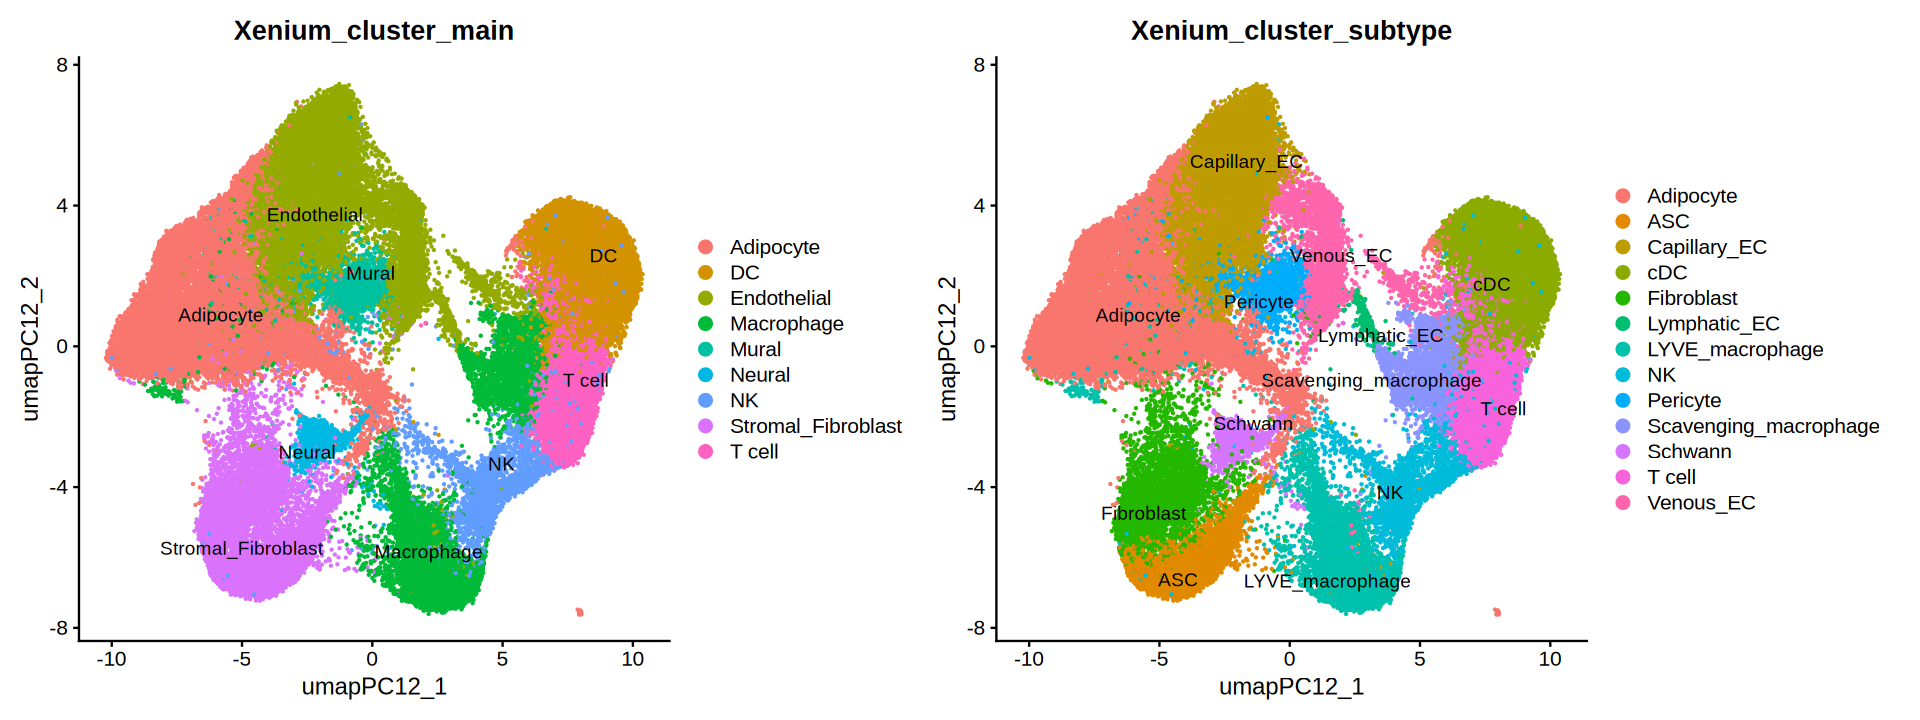

In [46]:
DimPlot(
  region_spatial,
  reduction = "umap_PC12",
  group.by = c("Xenium_cluster_main", "Xenium_cluster_subtype"),
  label = TRUE,
  repel = TRUE
)

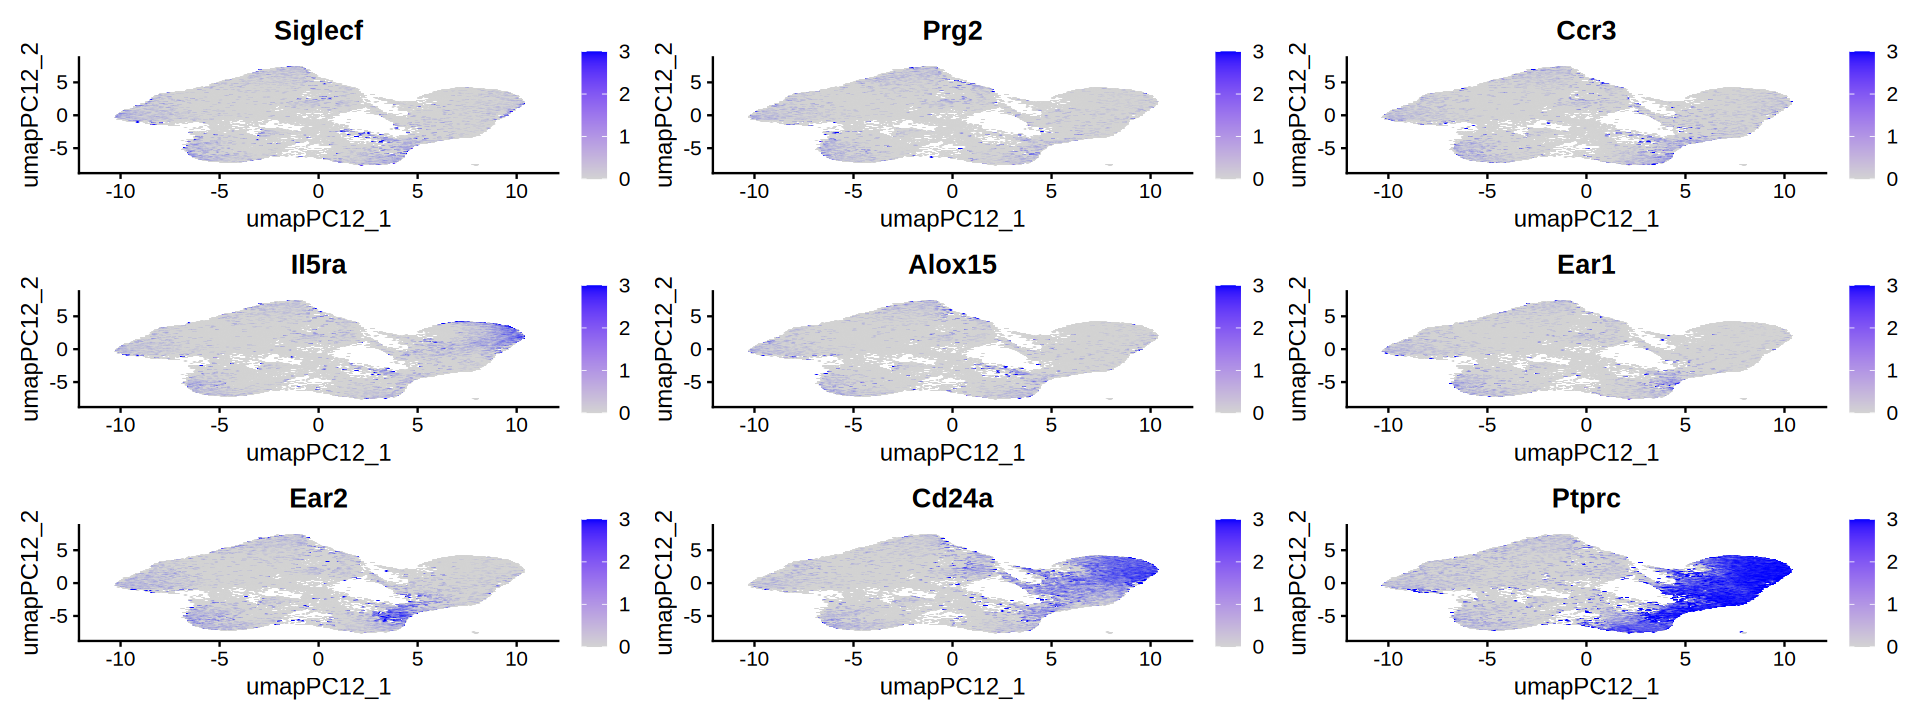

In [47]:
FeaturePlot(
    region_spatial,
    features = c(
        "Siglecf", "Prg2", "Ccr3",
        "Il5ra", "Alox15",
        "Ear1", "Ear2", "Cd24a", "Ptprc"
    ),
    reduction = "umap_PC12",
    raster = TRUE, 
    pt.size = 3, 
    max.cutoff = 3
)

In [48]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial.rds")))

### Cell Type Annotation M2 - By Reference

In [49]:
region_spatial = readRDS(file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial.rds")))

In [50]:
WANG_REFERENCE_PATH <- file.path(
  "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data",
  "Wang_Science2025_mouse_human",
  "analysis_mouse",
  "Wang_Science2025_cleaned_seurat.rds"
)

In [51]:
scwat_ref <- readRDS(WANG_REFERENCE_PATH)
DefaultAssay(scwat_ref) <- "RNA"

cat("Reference conditions:\n")
print(table(scwat_ref$Condition))

Reference conditions:

2.5 months  12 months 
     19252      21686 


In [52]:
scwat_ref$Wang_subtype_original <- as.character(
  scwat_ref$CellType_subtype
)

sort(unique(scwat_ref$Wang_subtype_original))

[1] "Arterial_EC"                "ASC"                       
 [3] "B"                          "Capillary_EC"              
 [5] "CCR2_inflammatory_Monocyte" "CCR7_migratory_DC"         
 [7] "cDC1"                       "cDC2"                      
 [9] "CP-1"                       "CP-2"                      
[11] "CP-A"                       "CX3CR1_Monocyte"           
[13] "Eosinophil"                 "Epithelial"                
[15] "IAP"                        "ILC2"                      
[17] "Inflammatory_Mac"           "LYVE1_resident_Mac"        
[19] "Mast cell"                  "MatureAdip"                
[21] "Mesothelial"                "Neutrophil"                
[23] "NK"                         "Pericyte"                  
[25] "Plasma"                     "RegFibro"                  
[27] "T"                          "TREM2_LAM"                 
[29] "γδ T"

In [53]:
# Explicit Wang subtype harmonization.
# Detailed immune labels are preserved.
# Closely related non-immune states are harmonized only for broad-lineage transfer.

wang_subtype_harmonization <- c(
  "ASC" = "ASC",
  "IAP" = "APC",
  "CP-1" = "APC",
  "CP-A" = "APC",
  "CP-2" = "APC",
  "RegFibro" = "APC",
  "MatureAdip" = "Adipocyte",
  "Pericyte" = "Mural",
  "Arterial_EC" = "Endothelial",
  "Capillary_EC" = "Endothelial",
  "Epithelial" = "Epithelial",
  "Mesothelial" = "Mesothelial",
  "T" = "T",
  "γδ T" = "γδ T",
  "NK" = "NK",
  "ILC2" = "ILC2",
  "B" = "B",
  "Plasma" = "Plasma",
  "CCR2_inflammatory_Monocyte" = "CCR2_inflammatory_Monocyte",
  "CX3CR1_Monocyte" = "CX3CR1_Monocyte",
  "Inflammatory_Mac" = "Inflammatory_Mac",
  "LYVE1_resident_Mac" = "LYVE1_resident_Mac",
  "TREM2_LAM" = "TREM2_LAM",
  "IFN_response_myeloid" = "IFN_response_myeloid",
  "cDC1" = "cDC1",
  "cDC2" = "cDC2",
  "CCR7_migratory_DC" = "CCR7_migratory_DC",
  "Neutrophil" = "Neutrophil",
  "Eosinophil" = "Eosinophil",
  "Mast cell" = "Mast cell"
)

unexpected_wang_labels <- setdiff(
  unique(scwat_ref$Wang_subtype_original),
  names(wang_subtype_harmonization)
)

if (length(unexpected_wang_labels)) {
  stop(
    "Unexpected Wang subtype labels. Review before proceeding: ",
    paste(unexpected_wang_labels, collapse = ", ")
  )
}

scwat_ref$Wang_subtype_harmonized <- unname(
  wang_subtype_harmonization[
    scwat_ref$Wang_subtype_original
  ]
)


In [54]:
scwat_ref$Wang_main <- case_when(
  scwat_ref$Wang_subtype_harmonized %in% c("ASC", "APC") ~ "Stromal_Fibroblast",
  scwat_ref$Wang_subtype_harmonized == "Mural" ~ "Mural",
  scwat_ref$Wang_subtype_harmonized == "Adipocyte" ~ "Adipocyte",
  scwat_ref$Wang_subtype_harmonized == "Endothelial" ~ "Endothelial",
  scwat_ref$Wang_subtype_harmonized == "Epithelial" ~ "Epithelial",
  scwat_ref$Wang_subtype_harmonized == "Mesothelial" ~ "Mesothelial",

  scwat_ref$Wang_subtype_harmonized %in% c("T", "γδ T") ~ "T cell",
  scwat_ref$Wang_subtype_harmonized == "NK" ~ "NK",
  scwat_ref$Wang_subtype_harmonized == "ILC2" ~ "ILC",
  scwat_ref$Wang_subtype_harmonized == "B" ~ "B cell",
  scwat_ref$Wang_subtype_harmonized == "Plasma" ~ "Plasma",

  scwat_ref$Wang_subtype_harmonized %in%
    c("CCR2_inflammatory_Monocyte", "CX3CR1_Monocyte") ~ "Monocyte",

  scwat_ref$Wang_subtype_harmonized %in%
    c("Inflammatory_Mac", "LYVE1_resident_Mac", "TREM2_LAM") ~ "Macrophage",

  scwat_ref$Wang_subtype_harmonized == "IFN_response_myeloid" ~ "Myeloid",

  scwat_ref$Wang_subtype_harmonized %in%
    c("cDC1", "cDC2", "CCR7_migratory_DC") ~ "DC",

  scwat_ref$Wang_subtype_harmonized == "Neutrophil" ~ "Neutrophil",
  scwat_ref$Wang_subtype_harmonized == "Eosinophil" ~ "Eosinophil",
  scwat_ref$Wang_subtype_harmonized == "Mast cell" ~ "Mast cell",

  TRUE ~ NA_character_
)

if (anyNA(scwat_ref$Wang_main)) {
  stop("Some Wang cells could not be mapped to the broad ontology.")
}

table(
  scwat_ref$Wang_main,
  scwat_ref$Wang_subtype_harmonized
)


                    
                     Adipocyte   APC   ASC     B CCR2_inflammatory_Monocyte
  Adipocyte                 40     0     0     0                          0
  B cell                     0     0     0  1241                          0
  DC                         0     0     0     0                          0
  Endothelial                0     0     0     0                          0
  Eosinophil                 0     0     0     0                          0
  Epithelial                 0     0     0     0                          0
  ILC                        0     0     0     0                          0
  Macrophage                 0     0     0     0                          0
  Mast cell                  0     0     0     0                          0
  Mesothelial                0     0     0     0                          0
  Monocyte                   0     0     0     0                       1256
  Mural                      0     0     0     0                   

In [55]:
# saveRDS(scwat_ref,WANG_REFERENCE_PATH)

In [57]:
annotation_genes <- Reduce(
  intersect,
  list(
    FIX_GENESET,
    rownames(scwat_ref),
    rownames(region_spatial)
  )
)

cat("Annotation features:", length(annotation_genes), "\n")

if (length(annotation_genes) < 100) {
  stop("Too few shared identity genes for reliable transfer; review gene symbols/panel.")
}

# Confirm short-/long-lived Eos state genes are excluded.
stopifnot(
  length(intersect(annotation_genes, eos_state_genes)) == 0
)

Annotation features: 374 


In [58]:
run_wang_transfer <- function(
  reference,
  query,
  annotation_genes,
  main_col = "Wang_main",
  subtype_col = "Wang_subtype_harmonized",
  prefix
) {

  DefaultAssay(reference) <- "RNA"

  # Restrict features to genes present in BOTH objects
  features_use <- Reduce(
    intersect,
    list(
      annotation_genes,
      rownames(reference),
      rownames(query)
    )
  )

  message(
    prefix,
    ": using ",
    length(features_use),
    " shared annotation genes"
  )

  reference <- NormalizeData(
    reference,
    assay = "RNA",
    verbose = FALSE
  )

  reference <- ScaleData(
    reference,
    assay = "RNA",
    features = features_use,
    verbose = FALSE
  )

  reference <- RunPCA(
    reference,
    assay = "RNA",
    features = features_use,
    npcs = 30,
    seed.use = 1234,
    verbose = FALSE
  )

  anchors <- FindTransferAnchors(
    reference = reference,
    query = query,
    reference.assay = "RNA",
    query.assay = "Xenium",
    normalization.method = "LogNormalize",
    reduction = "pcaproject",
    features = features_use,
    dims = 1:30,
    verbose = FALSE
  )

  pred_main <- TransferData(
    anchorset = anchors,
    refdata = reference[[main_col]][, 1],
    dims = 1:30,
    verbose = FALSE
  )

  pred_subtype <- TransferData(
    anchorset = anchors,
    refdata = reference[[subtype_col]][, 1],
    dims = 1:30,
    verbose = FALSE
  )

  # Rename output columns so 2.5m / 12m / all can coexist
  colnames(pred_main) <- paste0(
    prefix,
    "_main_",
    colnames(pred_main)
  )

  colnames(pred_subtype) <- paste0(
    prefix,
    "_subtype_",
    colnames(pred_subtype)
  )

  list(
    main = pred_main,
    subtype = pred_subtype,
    anchors = anchors,
    features = features_use
  )
}

In [59]:
ref_2p5 <- subset(
  scwat_ref,
  subset = Condition == "2.5 months"
)

ref_12 <- subset(
  scwat_ref,
  subset = Condition == "12 months"
)

ref_all <- scwat_ref

In [60]:
table(
  ref_2p5$Wang_subtype_harmonized
)

table(
  ref_12$Wang_subtype_harmonized
)

table(
  ref_all$Wang_subtype_harmonized
)


                 Adipocyte                        APC 
                        31                       6125 
                       ASC                          B 
                      1524                        715 
CCR2_inflammatory_Monocyte          CCR7_migratory_DC 
                       653                         39 
                      cDC1                       cDC2 
                       465                        158 
           CX3CR1_Monocyte                Endothelial 
                       181                        917 
                Eosinophil                 Epithelial 
                        19                        413 
                      ILC2           Inflammatory_Mac 
                       473                        357 
        LYVE1_resident_Mac                  Mast cell 
                      3200                         28 
               Mesothelial                      Mural 
                       550                        827 
         


                 Adipocyte                        APC 
                         9                       8115 
                       ASC                          B 
                      4525                        526 
CCR2_inflammatory_Monocyte          CCR7_migratory_DC 
                       603                         74 
                      cDC1                       cDC2 
                       380                         89 
           CX3CR1_Monocyte                Endothelial 
                       389                        402 
                Eosinophil                 Epithelial 
                       161                        212 
                      ILC2           Inflammatory_Mac 
                       278                        271 
        LYVE1_resident_Mac                  Mast cell 
                      1892                         24 
               Mesothelial                      Mural 
                      1306                        801 
         


                 Adipocyte                        APC 
                        40                      14240 
                       ASC                          B 
                      6049                       1241 
CCR2_inflammatory_Monocyte          CCR7_migratory_DC 
                      1256                        113 
                      cDC1                       cDC2 
                       845                        247 
           CX3CR1_Monocyte                Endothelial 
                       570                       1319 
                Eosinophil                 Epithelial 
                       180                        625 
                      ILC2           Inflammatory_Mac 
                       751                        628 
        LYVE1_resident_Mac                  Mast cell 
                      5092                         52 
               Mesothelial                      Mural 
                      1856                       1628 
         

In [61]:
length(annotation_genes)

[1] 374

In [62]:
transfer_2p5 <- run_wang_transfer(
  reference = ref_2p5,
  query = region_spatial,
  annotation_genes = annotation_genes,
  prefix = "Ref2p5"
)

transfer_12 <- run_wang_transfer(
  reference = ref_12,
  query = region_spatial,
  annotation_genes = annotation_genes,
  prefix = "Ref12"
)

transfer_all <- run_wang_transfer(
  reference = ref_all,
  query = region_spatial,
  annotation_genes = annotation_genes,
  prefix = "RefAll"
)

Ref2p5: using 374 shared annotation genes

Warning message:
“Number of dimensions changing from 50 to 30”
Ref12: using 374 shared annotation genes

Warning message:
“Number of dimensions changing from 50 to 30”
RefAll: using 374 shared annotation genes

Warning message:
“Number of dimensions changing from 50 to 30”


In [63]:
region_spatial <- AddMetaData(
  region_spatial,
  metadata = transfer_2p5$main
)

region_spatial <- AddMetaData(
  region_spatial,
  metadata = transfer_2p5$subtype
)

region_spatial <- AddMetaData(
  region_spatial,
  metadata = transfer_12$main
)

region_spatial <- AddMetaData(
  region_spatial,
  metadata = transfer_12$subtype
)

region_spatial <- AddMetaData(
  region_spatial,
  metadata = transfer_all$main
)

region_spatial <- AddMetaData(
  region_spatial,
  metadata = transfer_all$subtype
)

In [64]:
table(
  region_spatial$RefAll_subtype_predicted.id
)


                 Adipocyte                        APC 
                     14309                       9231 
                       ASC                          B 
                      3855                       5541 
CCR2_inflammatory_Monocyte          CCR7_migratory_DC 
                      1616                        192 
                      cDC1                       cDC2 
                      2115                       2310 
           CX3CR1_Monocyte                Endothelial 
                       965                      15106 
                Eosinophil                 Epithelial 
                        69                         93 
                      ILC2           Inflammatory_Mac 
                       276                        254 
        LYVE1_resident_Mac                  Mast cell 
                      6655                          7 
               Mesothelial                      Mural 
                      1084                       3763 
         

In [65]:
options(repr.plot.width=15, repr.plot.height=15)

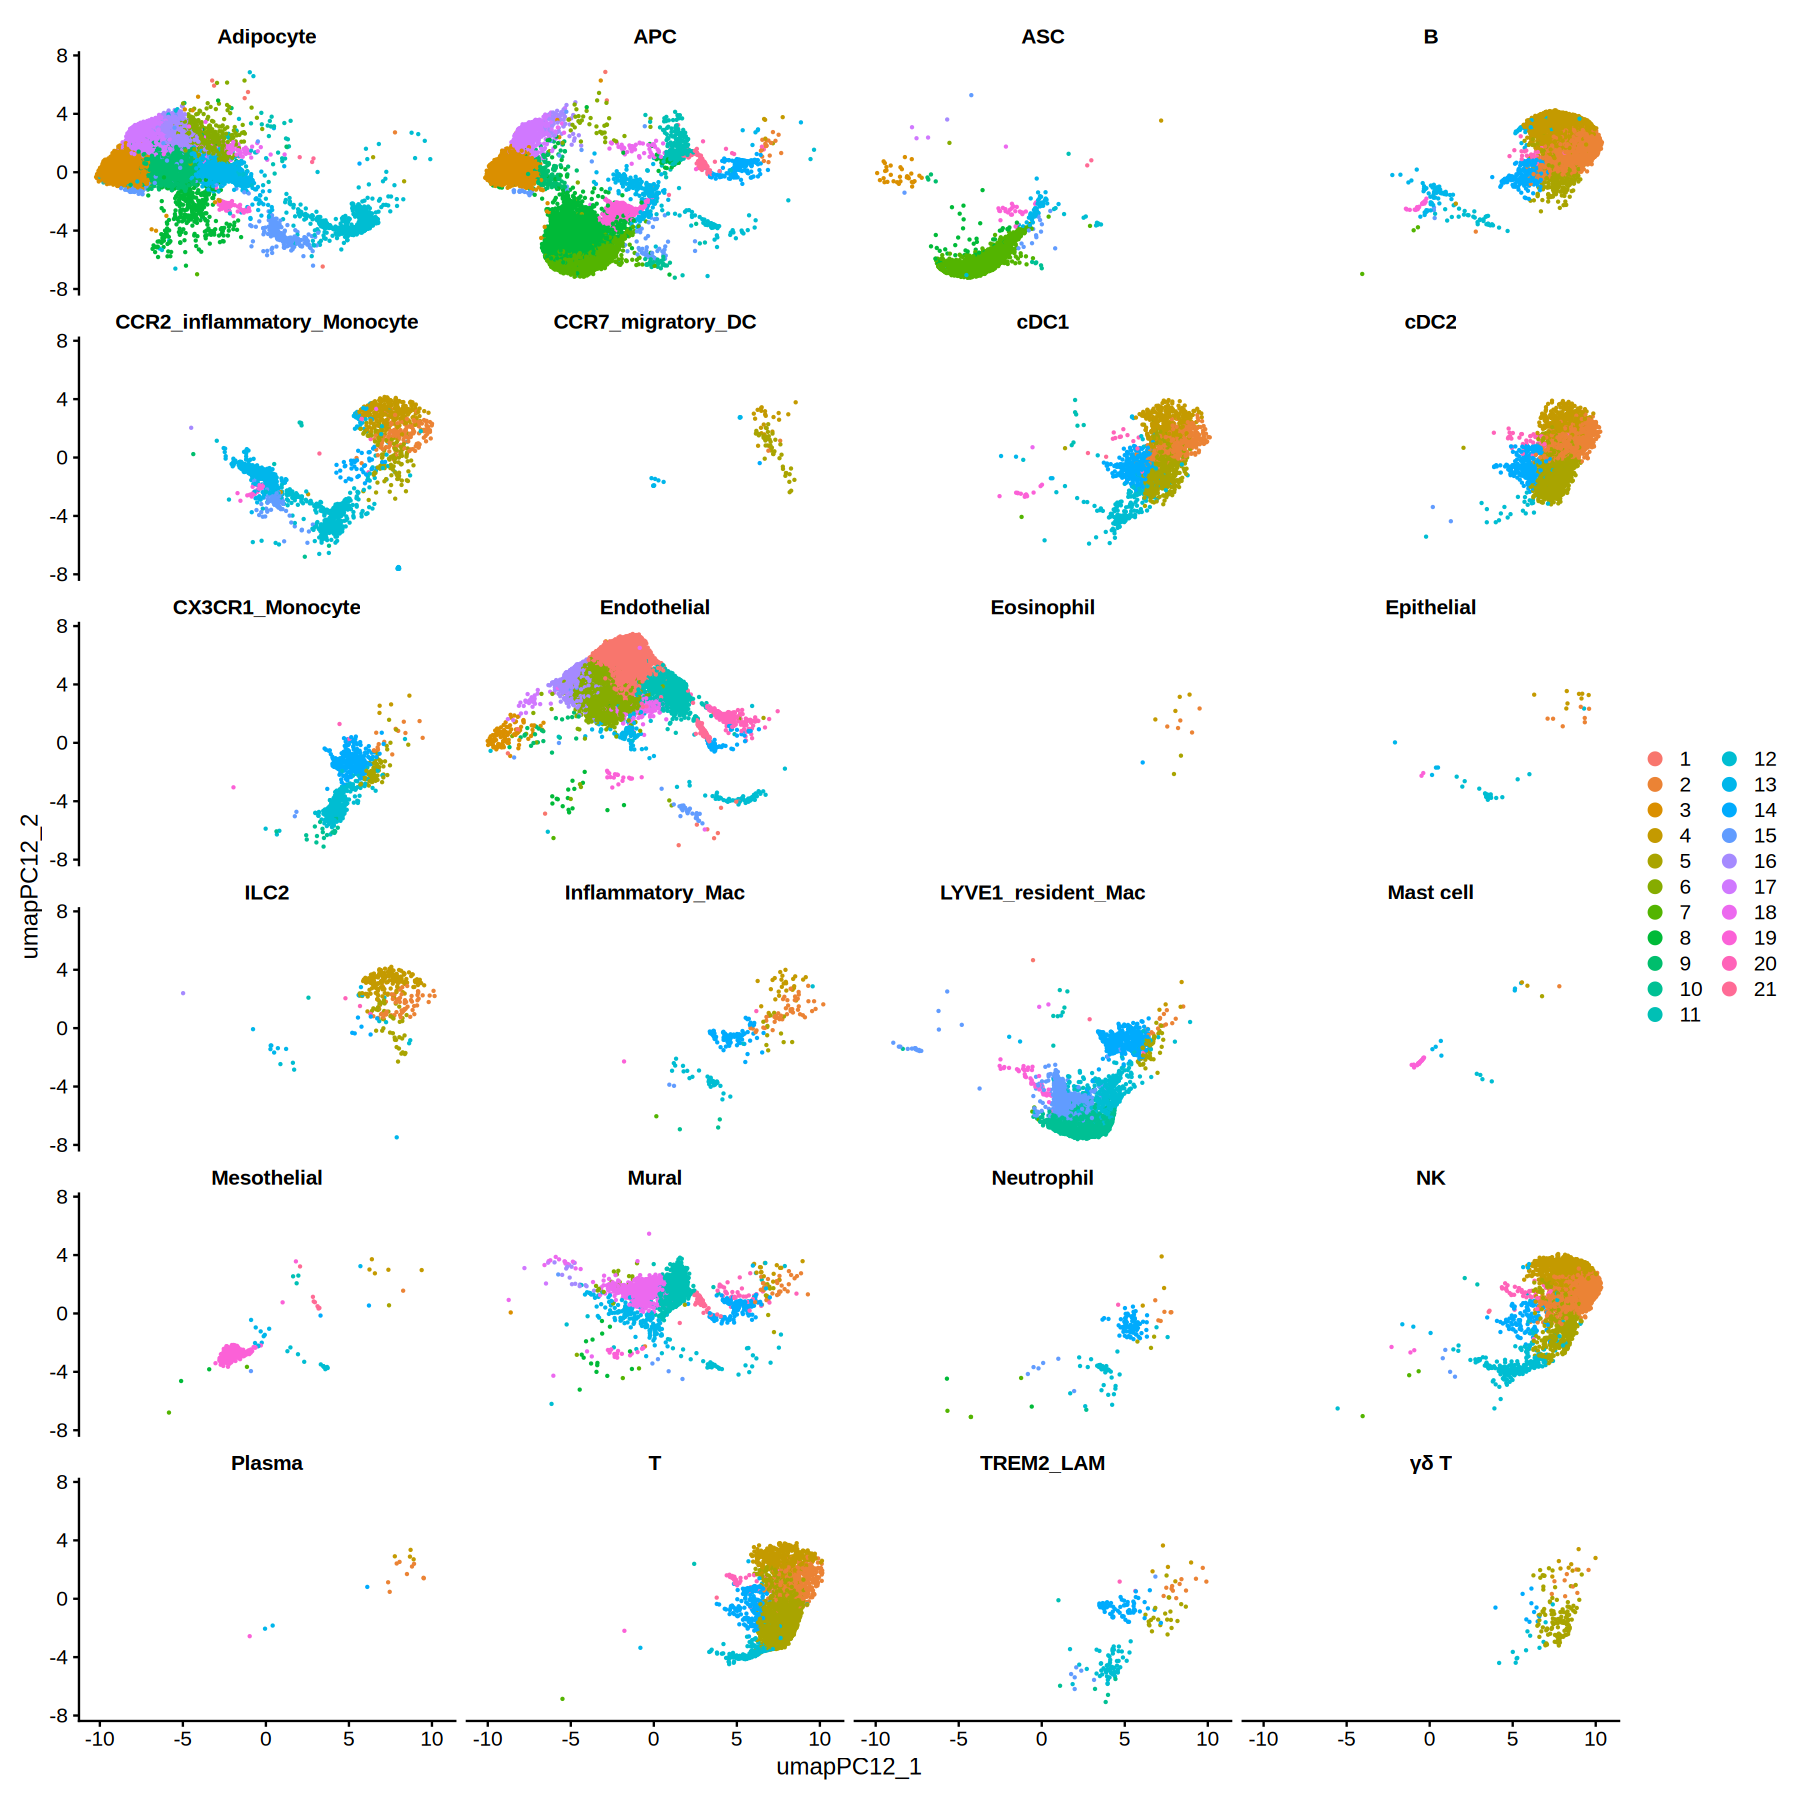

In [66]:
DimPlot(
  region_spatial,
  reduction = "umap_PC12",
  split.by = "Ref2p5_subtype_predicted.id",
  ncol=4
)

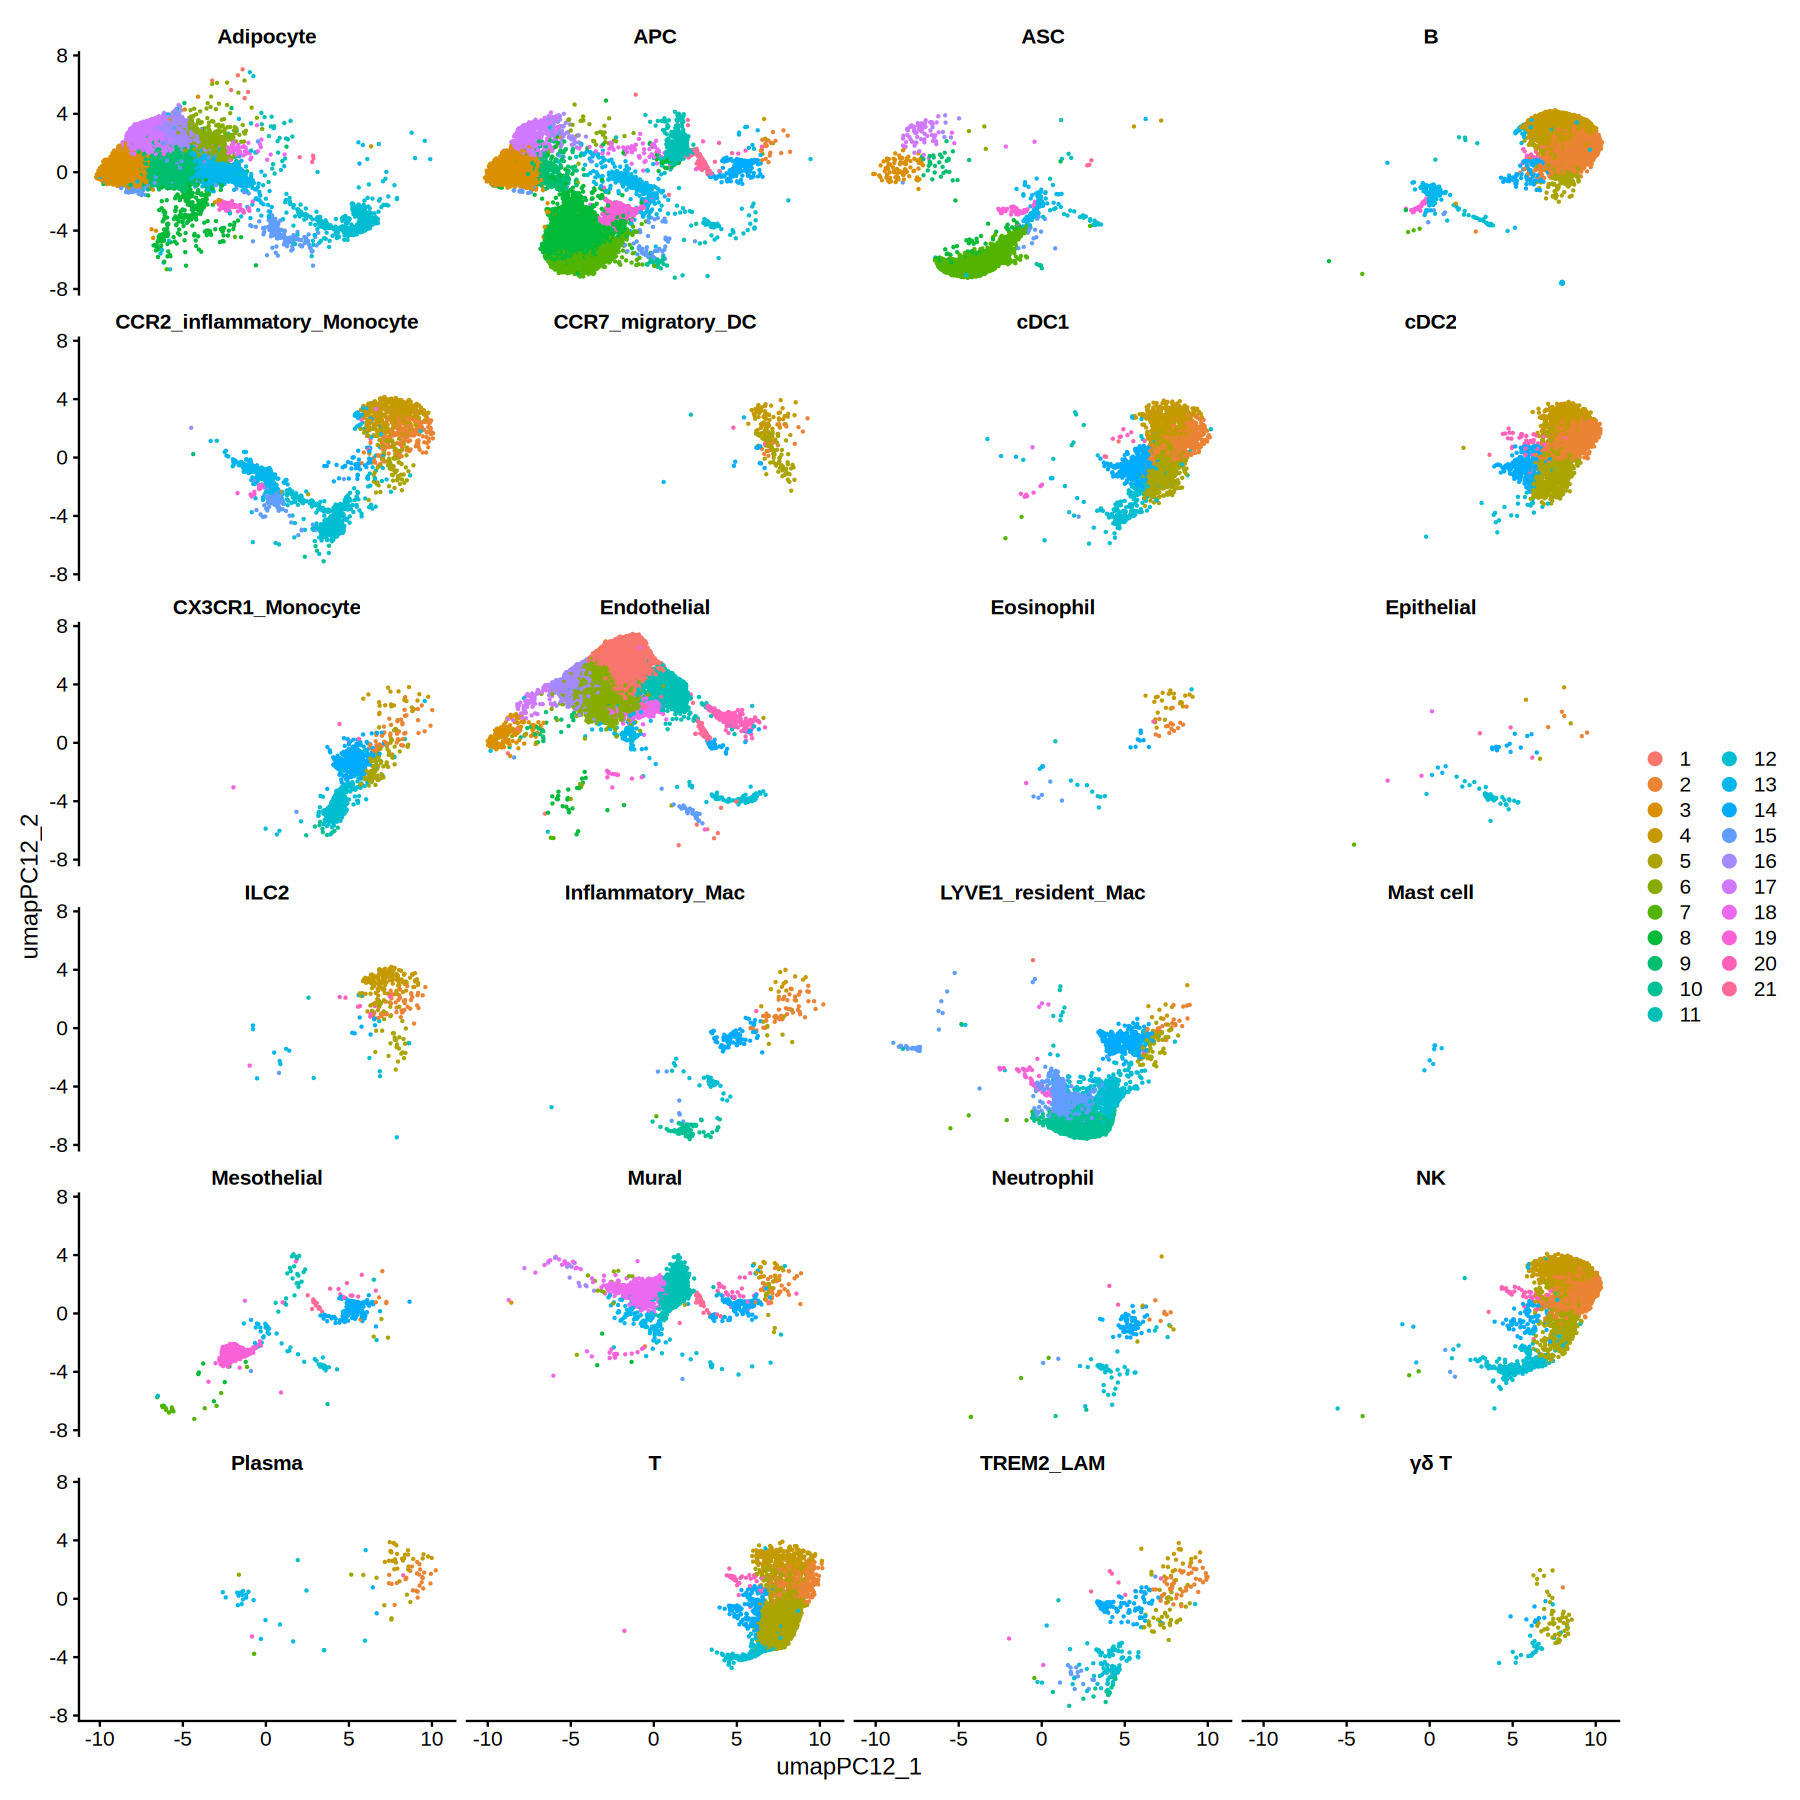

In [67]:
DimPlot(
  region_spatial,
  reduction = "umap_PC12",
  split.by = "RefAll_subtype_predicted.id",
  ncol=4
)

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


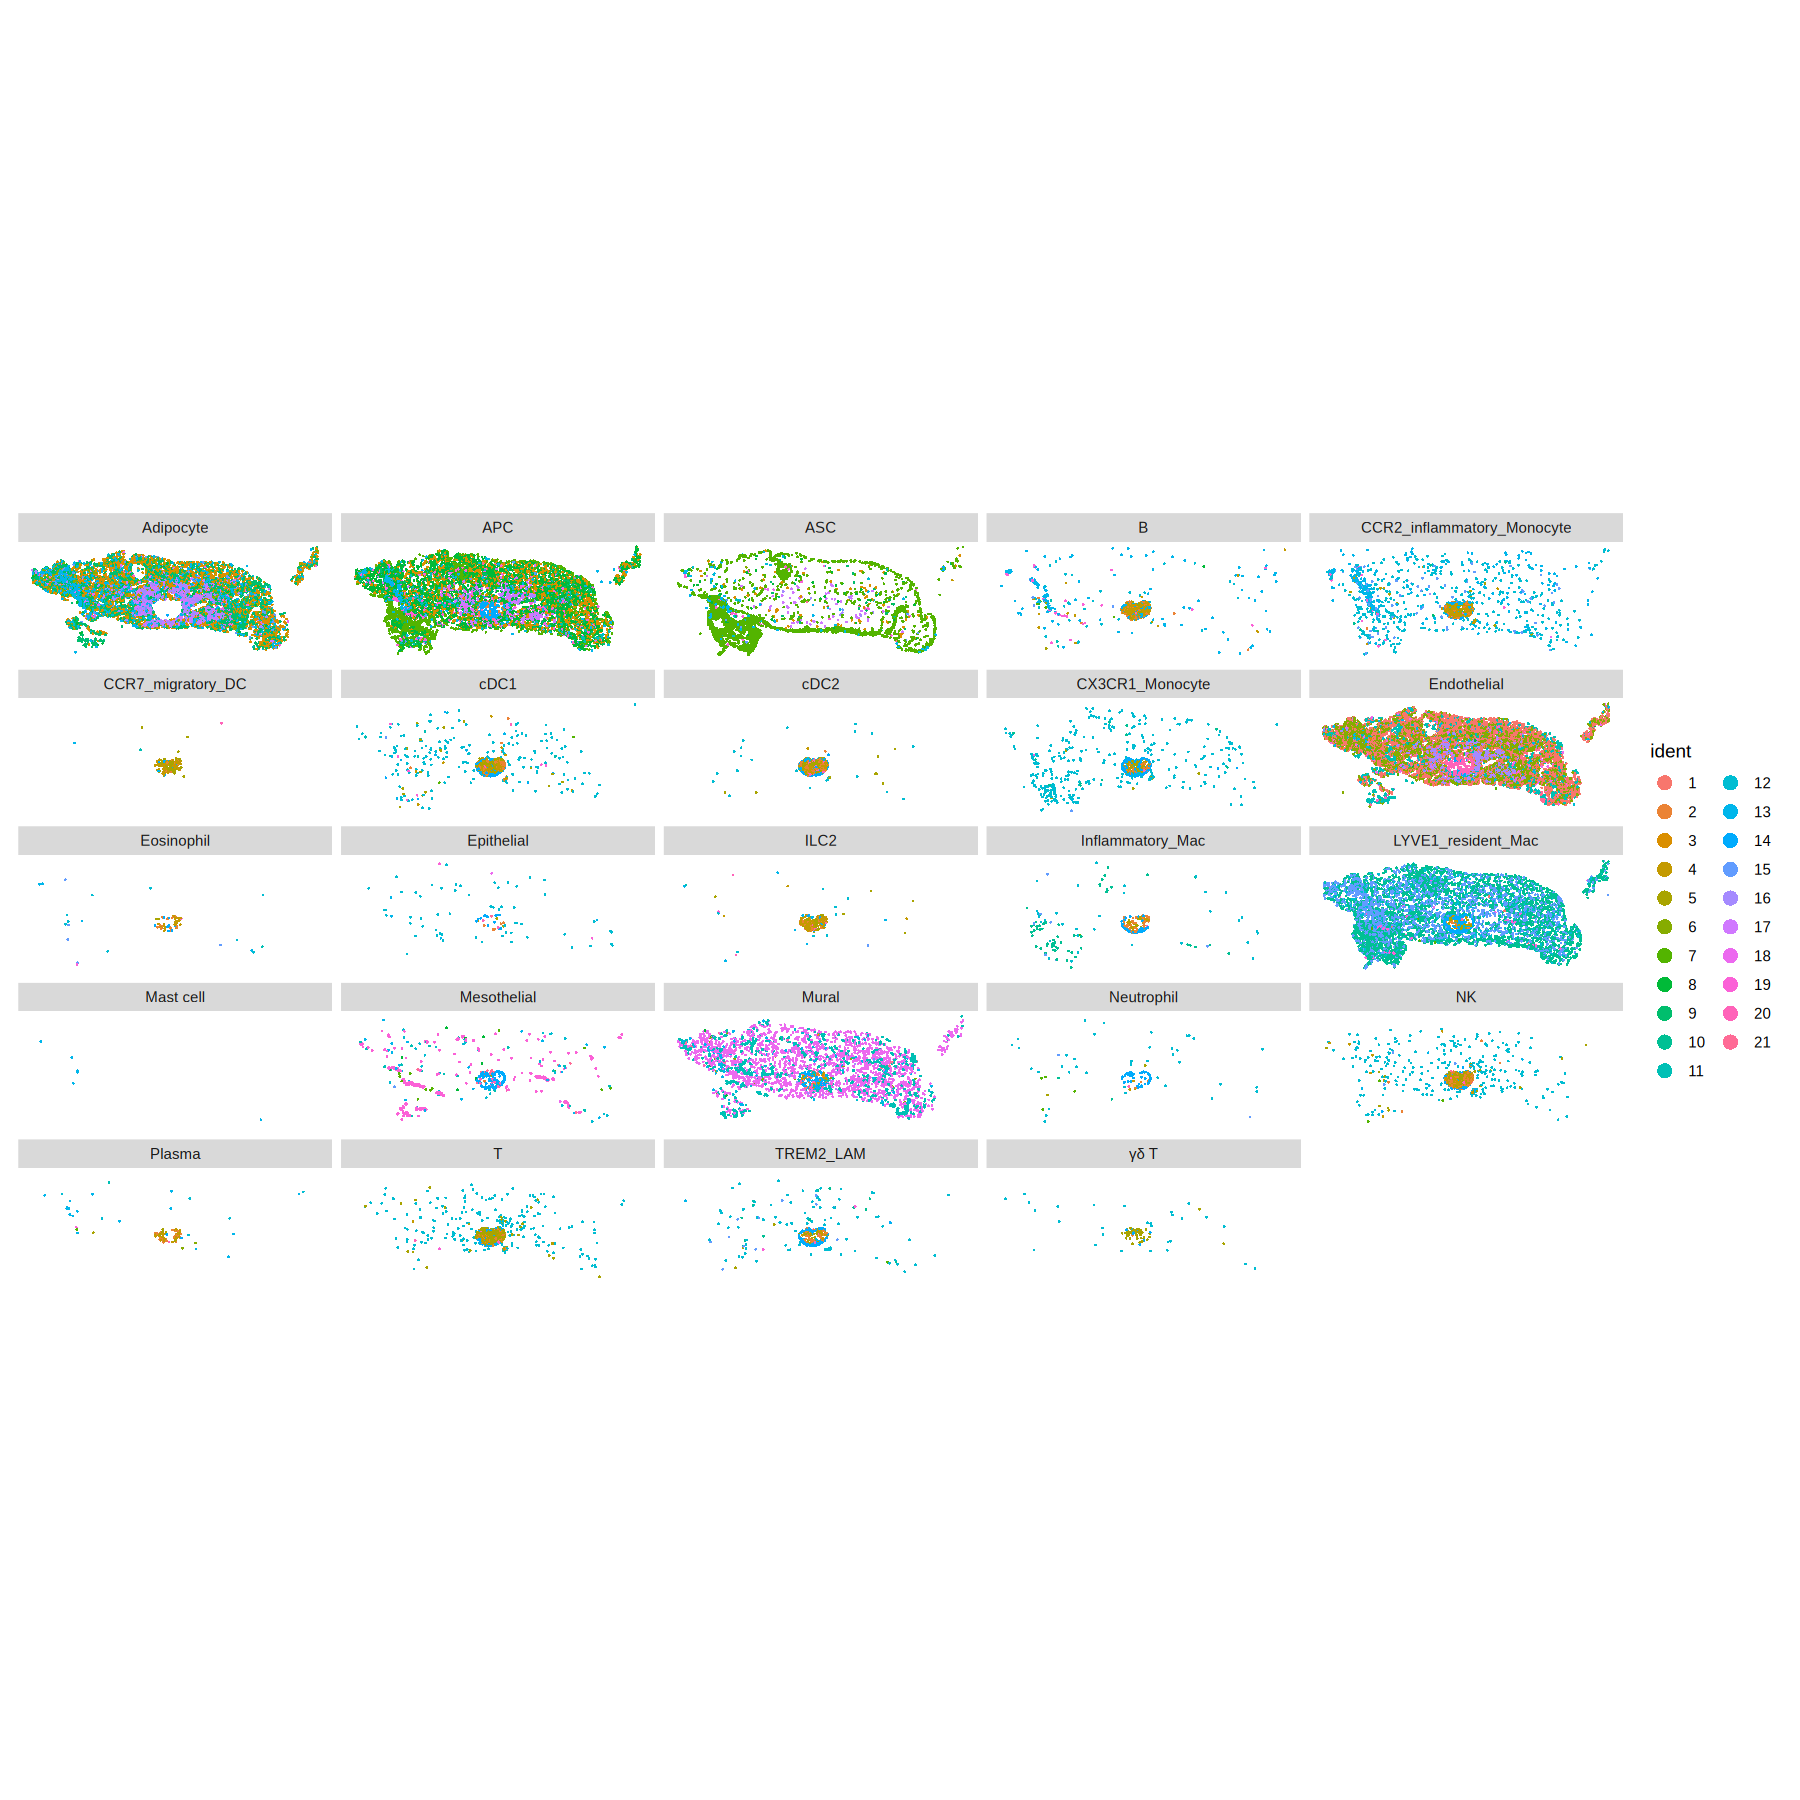

In [68]:
ImageDimPlot(
  region_spatial,
  fov = "fov",
  split.by = "RefAll_subtype_predicted.id",
  flip_xy = FALSE,
  dark.background = FALSE
)

In [69]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial.rds")))

In [70]:
options(repr.plot.width=15, repr.plot.height=10)

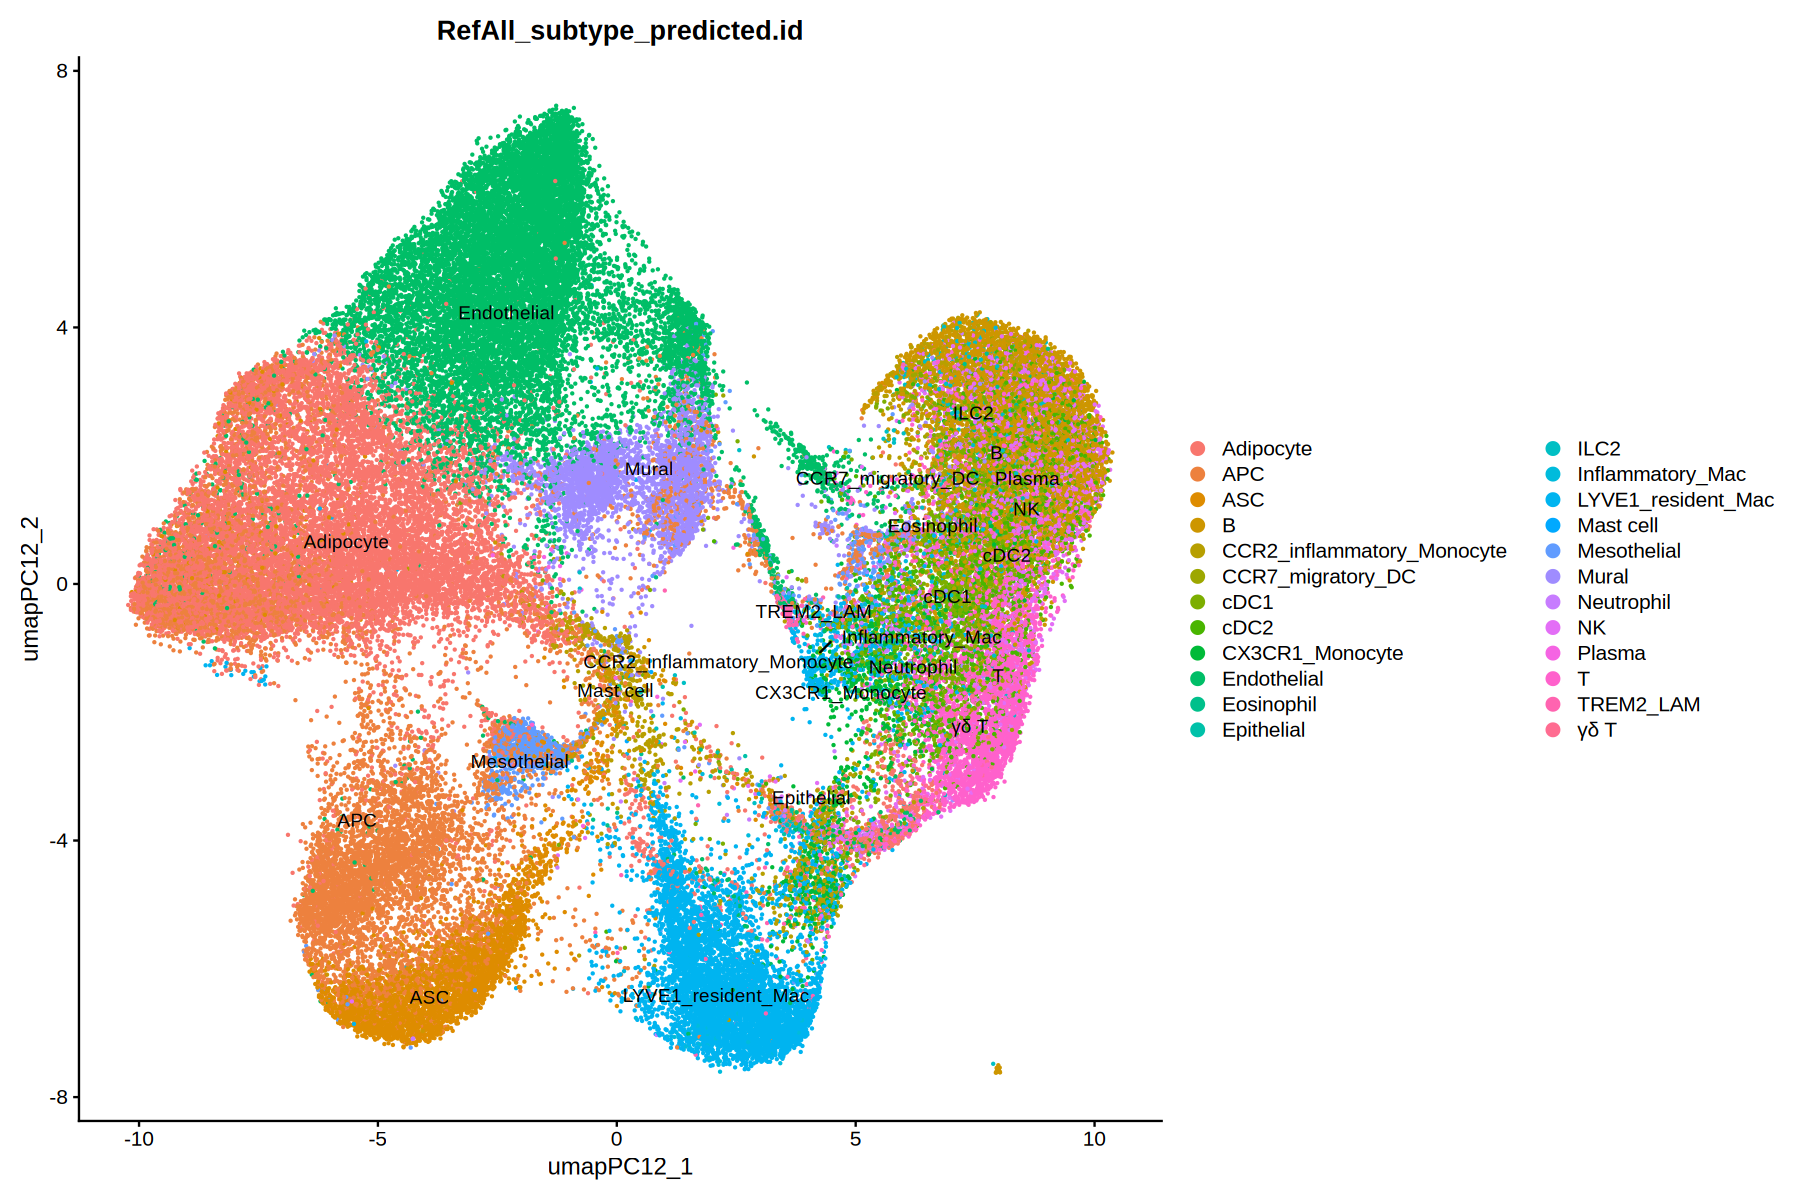

In [71]:
DimPlot(
  region_spatial,
  reduction = "umap_PC12",
  group.by = c("RefAll_subtype_predicted.id"),
  label = TRUE,
  repel = TRUE
)

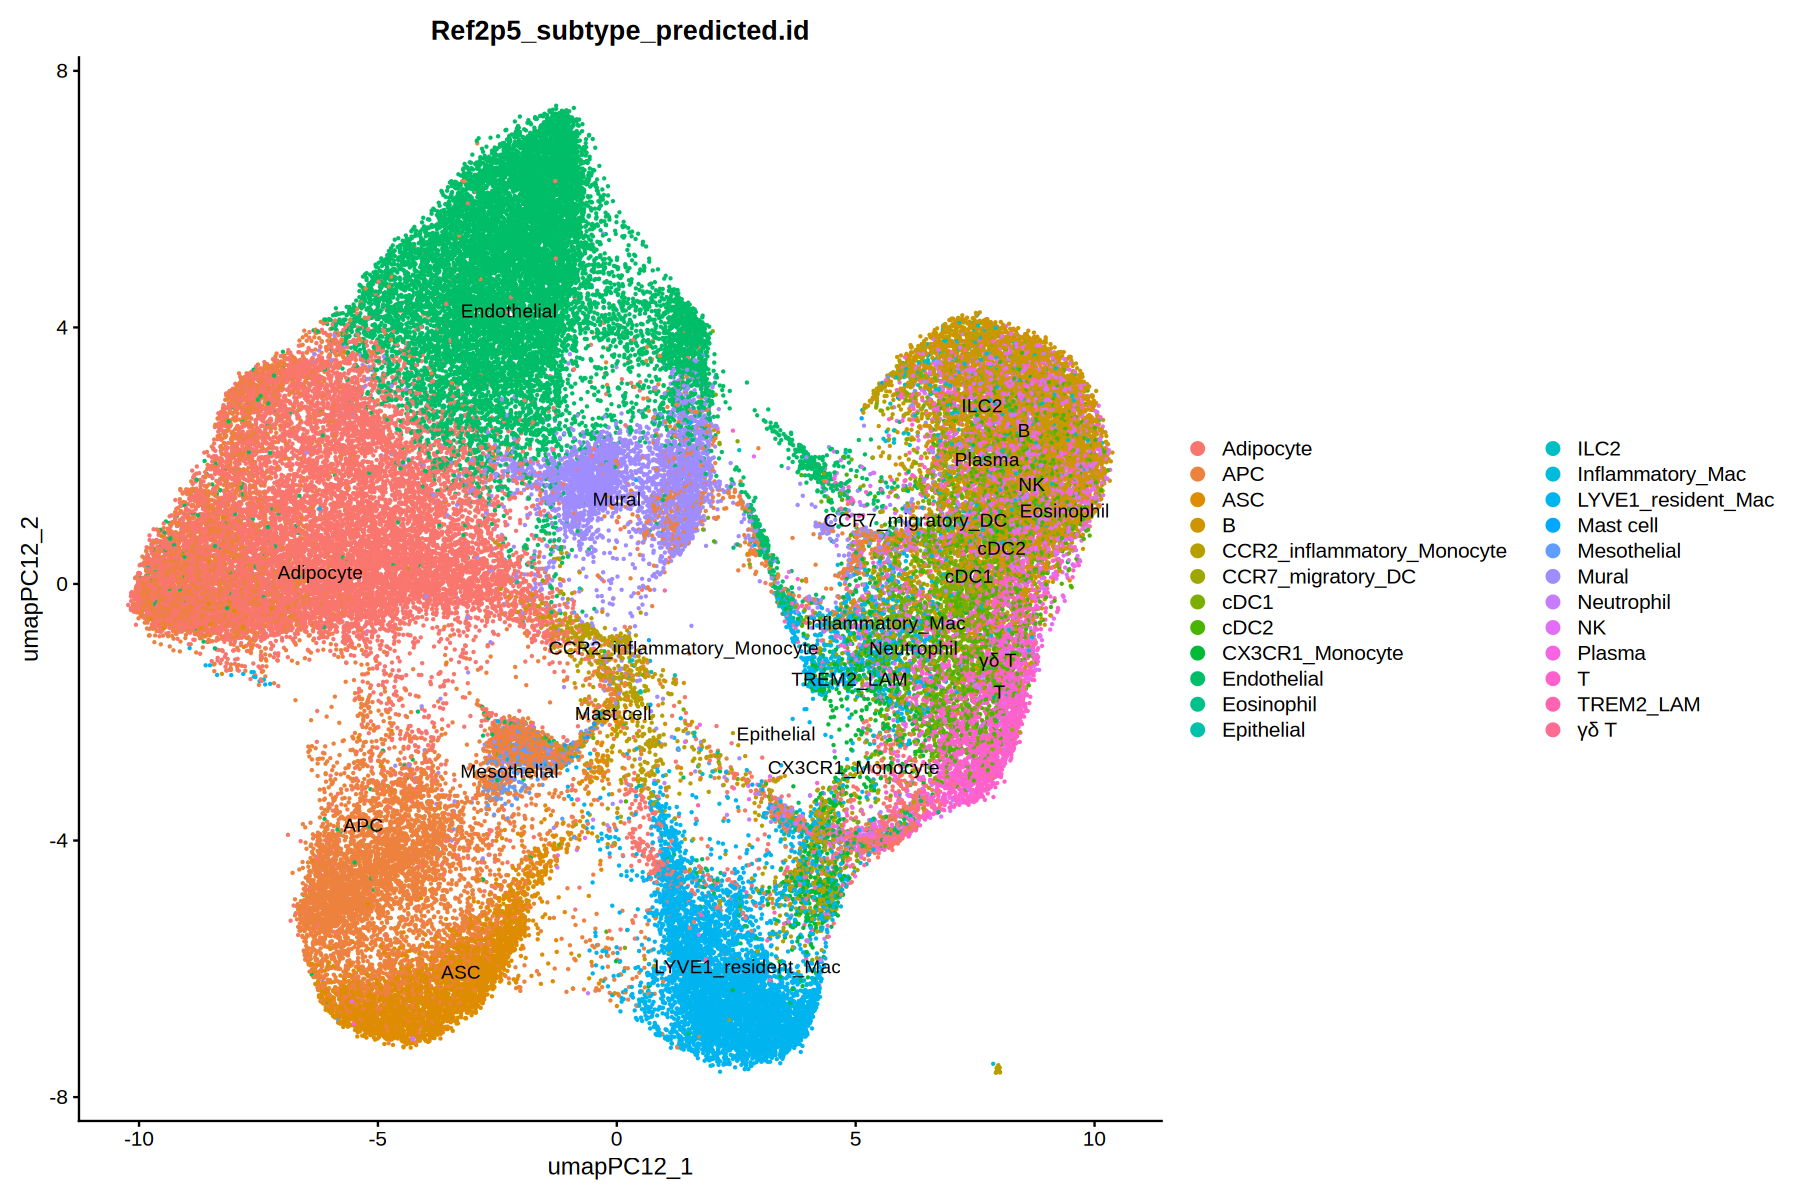

In [72]:
DimPlot(
  region_spatial,
  reduction = "umap_PC12",
  group.by = c("Ref2p5_subtype_predicted.id"),
  label = TRUE,
  repel = TRUE
)

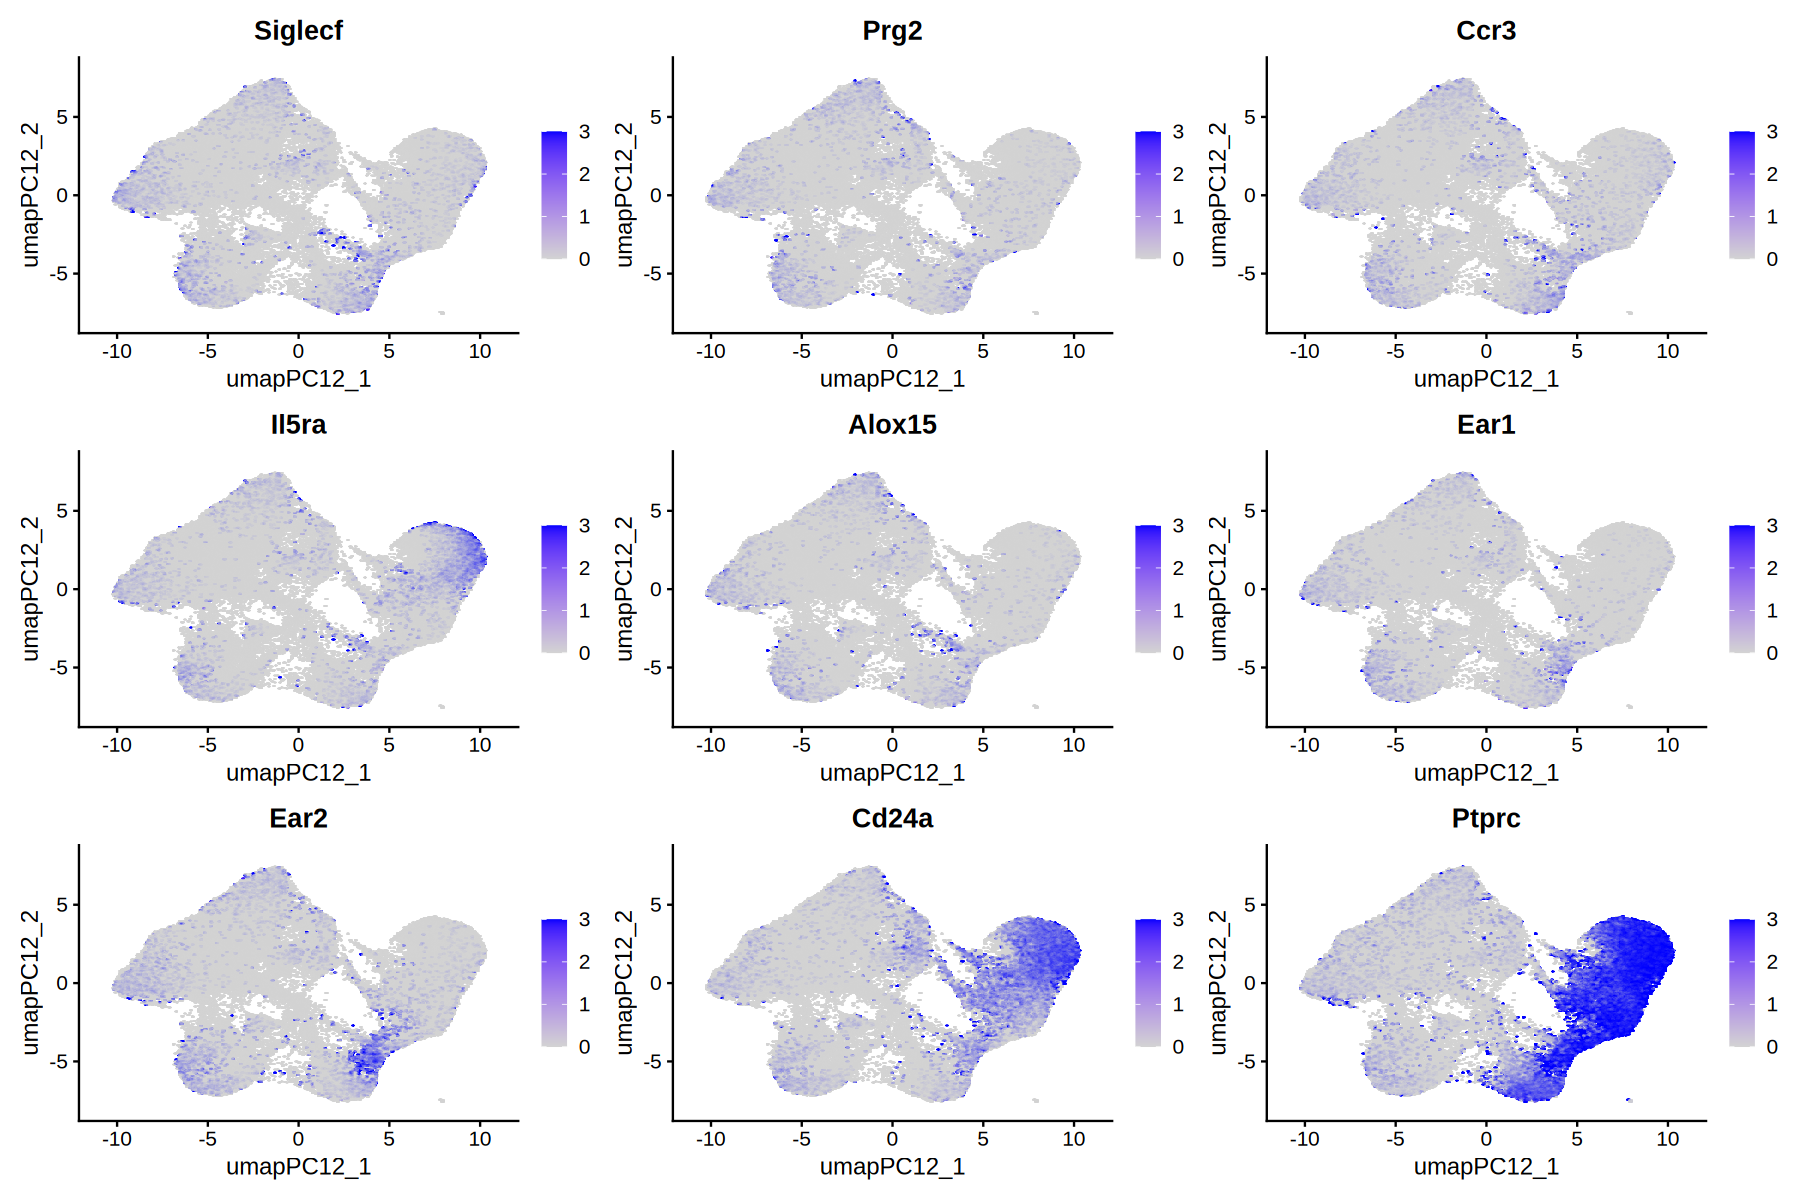

In [73]:
FeaturePlot(
    region_spatial,
    features = c(
        "Siglecf", "Prg2", "Ccr3",
        "Il5ra", "Alox15",
        "Ear1", "Ear2", "Cd24a", "Ptprc"
    ),
    reduction = "umap_PC12",
    raster = TRUE, 
    pt.size = 3, 
    max.cutoff = 3
)

### Refine cell types

In [76]:
annotation_result <- refine_xenium_celltypes(
  object = region_spatial,
  reduction = "pca",
  dims = 1:12,
  k = 15,
  self_weight = 0.70
)

region_spatial <- annotation_result$object

Building transcriptomic kNN: k = 15, reduction = pca, dims = 1:12

Annotation complete.

Review cells: 23101 / 74364 (31.06%)

Schwann ontology-gap rescue: 1043

Lymphatic EC ontology-gap rescue: 217



In [77]:
annotation_result$summary[annotation_result$summary$Final_CellType_subtype=='Eosinophil',]

,Final_CellType_main,Final_CellType_subtype,Final_annotation_source,Final_annotation_confidence,Final_review_flag,n_cells
,<chr>,<chr>,<chr>,<chr>,<lgl>,<int>
20,Eosinophil,Eosinophil,Wang_RefAll_immune,REFERENCE_PRIMARY,FALSE,17
21,Eosinophil,Eosinophil,Wang_RefAll_immune,HIGH_CONCORDANT,FALSE,3
22,Eosinophil,Eosinophil,Wang_RefAll_immune,REVIEW,TRUE,1


In [78]:
table(
  region_spatial$Final_CellType_main[region_spatial$Final_annotation_confidence=="REVIEW"],
  useNA = "ifany"
)

table(
  region_spatial$Final_CellType_subtype[region_spatial$Final_annotation_confidence=="REVIEW"],
  useNA = "ifany"
)

table(
  region_spatial$Final_annotation_confidence
)

table(
  region_spatial$Final_review_flag
)


         Adipocyte             B cell                 DC        Endothelial 
              1934                181                120              11545 
        Eosinophil         Epithelial                ILC         Macrophage 
                 1                 76                  3                253 
       Mesothelial           Monocyte              Mural         Neutrophil 
               330                 60                560                  1 
                NK             Plasma Stromal_Fibroblast             T cell 
                34                  3               7959                 41 


                 Adipocyte                        APC 
                      1934                       7352 
                       ASC                          B 
                       607                        181 
              Capillary_EC CCR2_inflammatory_Monocyte 
                     10195                         49 
         CCR7_migratory_DC                       cDC1 
                         8                         47 
                      cDC2            CX3CR1_Monocyte 
                        65                         11 
                Eosinophil                 Epithelial 
                         1                         76 
                      ILC2           Inflammatory_Mac 
                         3                         20 
              Lymphatic_EC         LYVE1_resident_Mac 
                       352                        130 
               Mesothelial                 Neutrophil 
                       330                          1 
         


       HIGH_CONCORDANT ONTOLOGY_GAP_SUPPORTED      REFERENCE_PRIMARY 
                 34959                   1260                  15044 
                REVIEW 
                 23101 


FALSE  TRUE 
51263 23101 

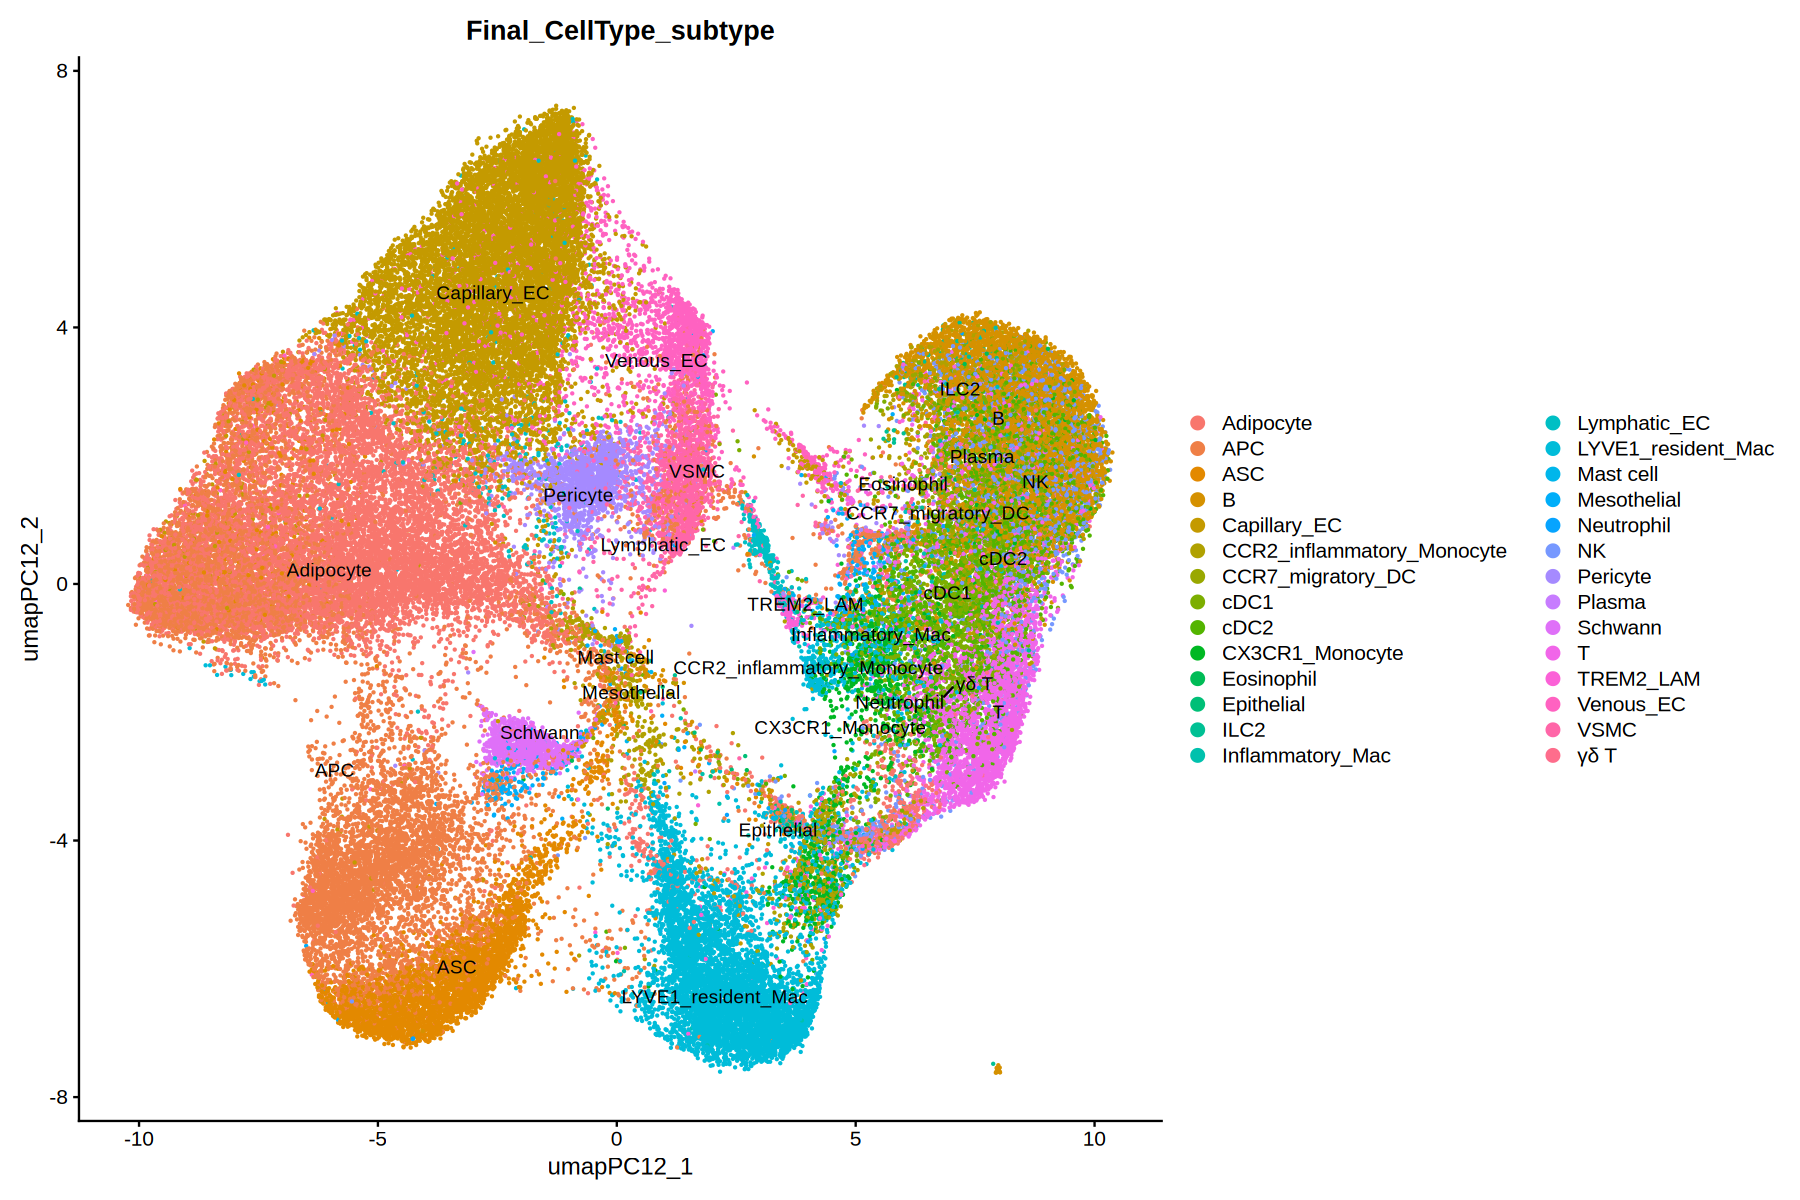

In [79]:
DimPlot(
  region_spatial,
  reduction = "umap_PC12",
  group.by = c("Final_CellType_subtype"),
  label = TRUE,
  repel = TRUE
)

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


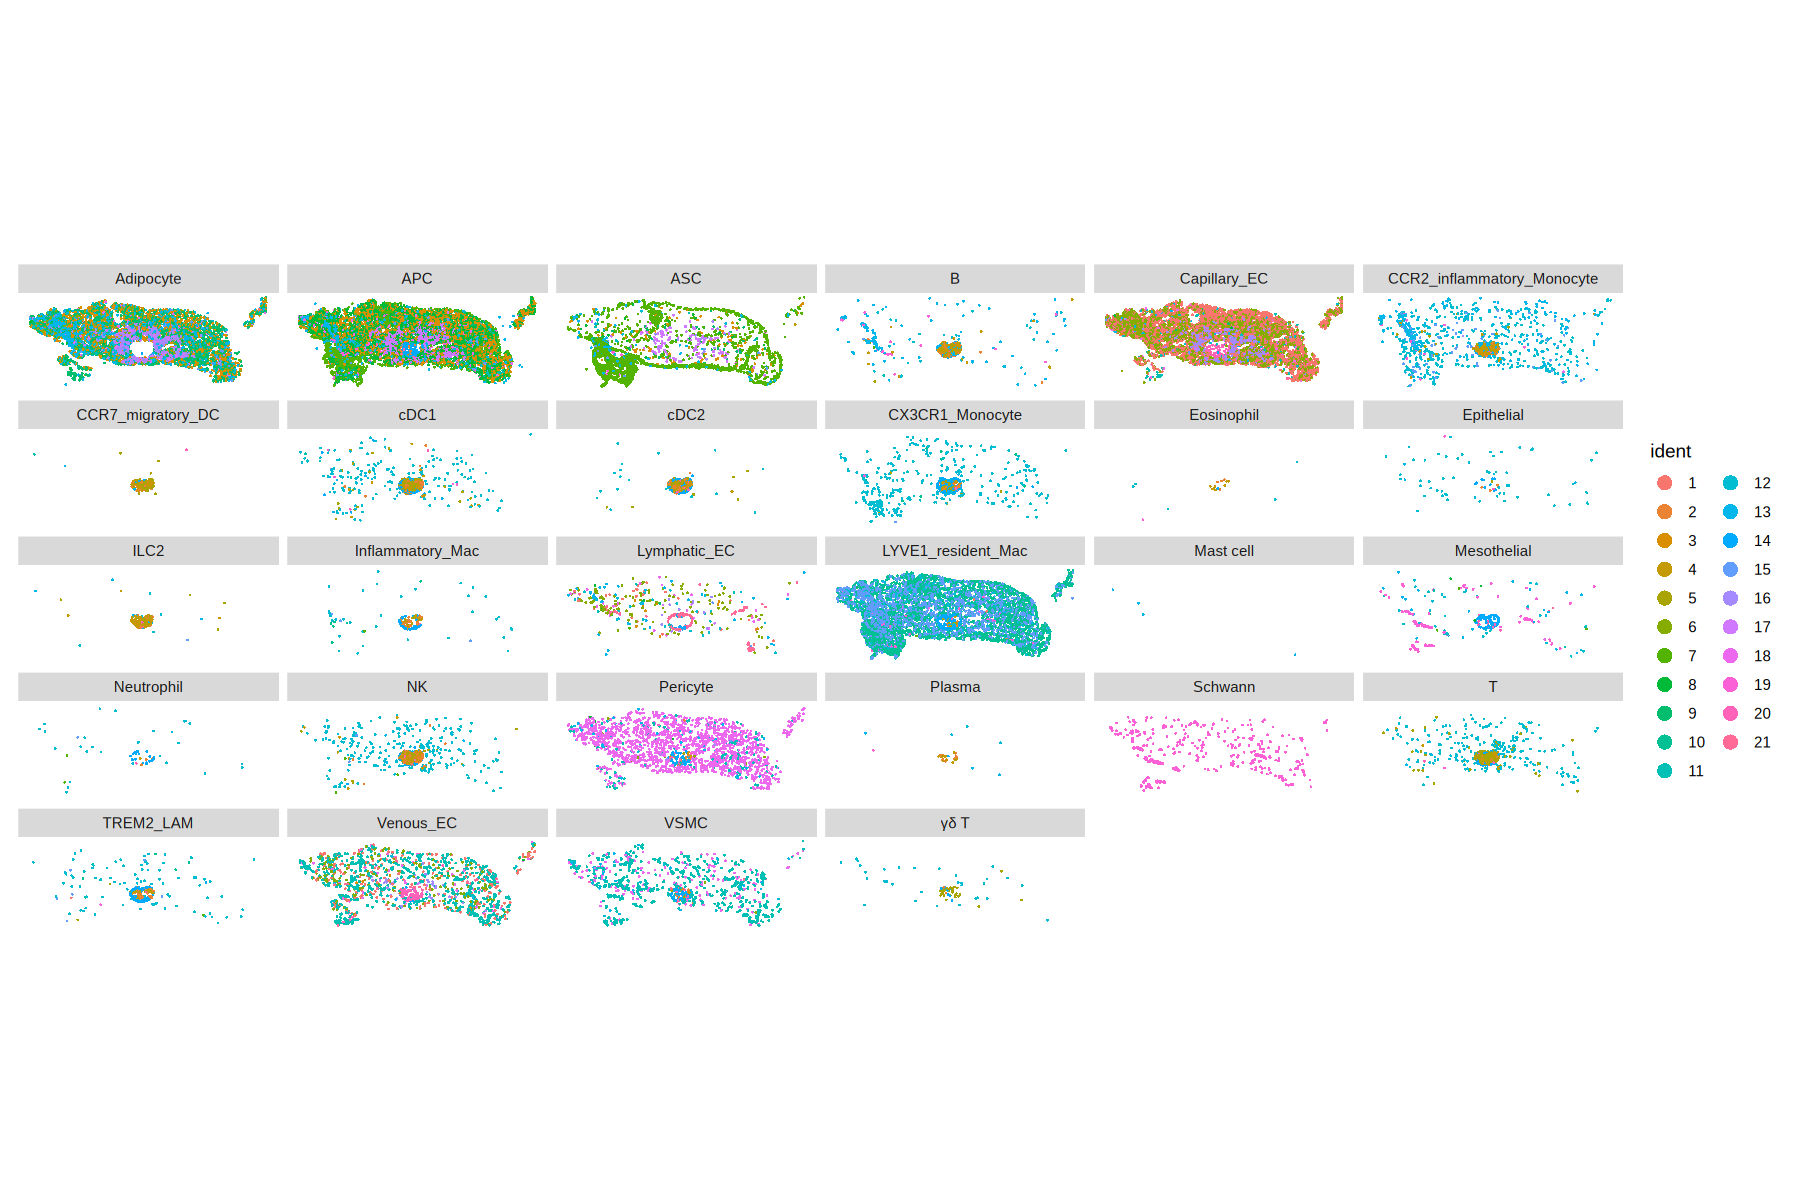

In [80]:
ImageDimPlot(
  region_spatial,
  fov = "fov",
  split.by = "Final_CellType_subtype",
  flip_xy = FALSE,
  dark.background = FALSE
)

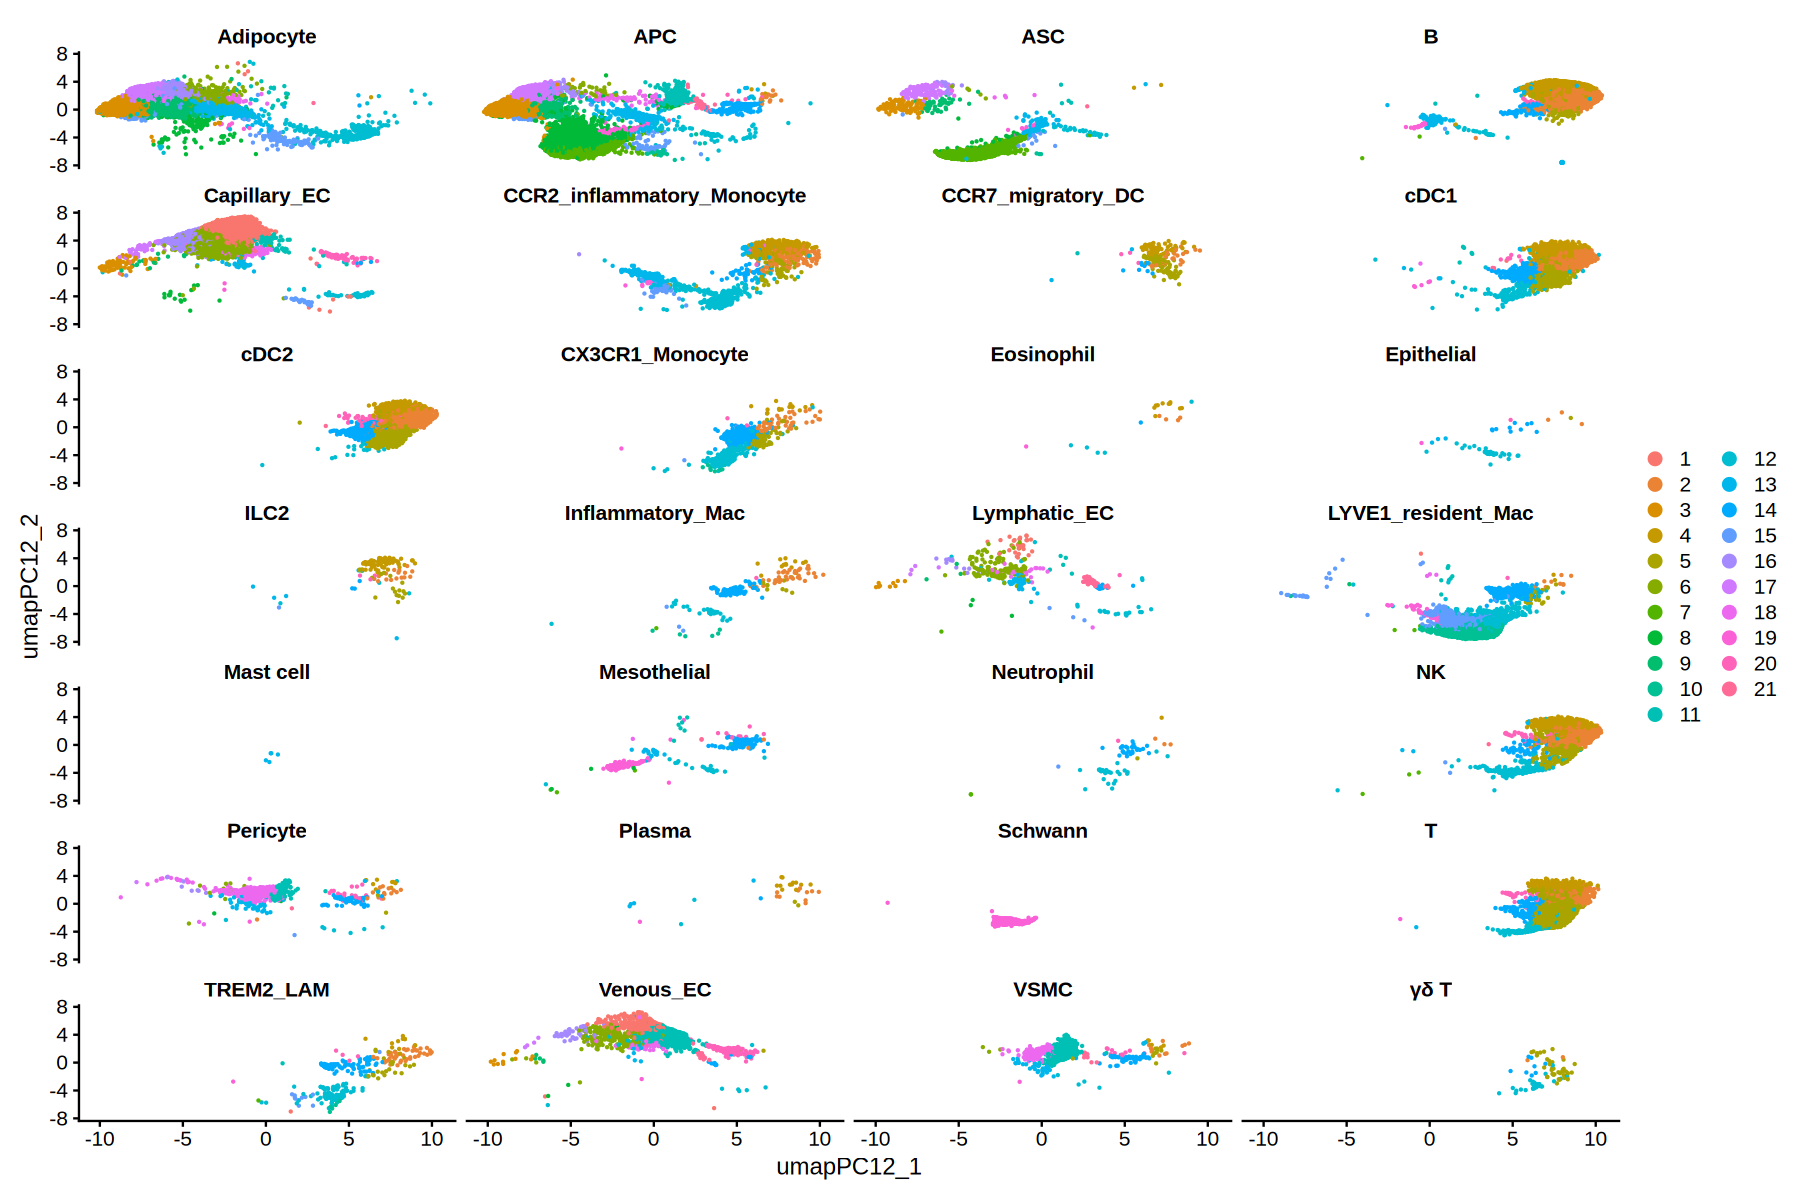

In [81]:
DimPlot(
  region_spatial,
  reduction = "umap_PC12",
  split.by = "Final_CellType_subtype",
  ncol=4
)

In [82]:
saveRDS(region_spatial, file.path(ANCHOR_ROOT, paste0(REGION_ID, "_spatial.rds")))

In [91]:
rownames(region_spatial@meta.data)[region_spatial@meta.data$Final_CellType_subtype == "Eosinophil"]

[1] "alalakkb-1" "bcncbemn-1" "cjbamkmf-1" "dbojgnii-1" "decenlml-1"
 [6] "gcgolbij-1" "ihhnhpah-1" "ingedkhm-1" "jechfoni-1" "jmefcddg-1"
[11] "jnamlobg-1" "jplokcic-1" "kepekncg-1" "kpdpifeg-1" "lgjkipmg-1"
[16] "lhffdkcb-1" "obcpgjfo-1" "oblbpjoc-1" "ogofdjlk-1" "ohcdhdpp-1"
[21] "ohikffpl-1"

In [84]:
eos_result <- refine_eosinophil_identity(
  object = region_spatial,
  assay = "Xenium",
  reduction = "pca",
  dims = 1:12,
  k = 15,
  self_weight = 0.70
)

region_spatial <- eos_result$object

Building transcriptomic kNN: k = 15; PCs = 1:12

Core Eos identity genes available: Siglecf, Ccr3, Il5ra, Prg2

Support Eos identity genes available: Alox15, Ear1, Ear2, Ltc4s

Eosinophil refinement complete.

HIGH_CONFIDENCE_EOS: 0

PROBABLE_EOS: 0

AMBIGUOUS_EOS: 7720

Core identity genes used: Siglecf, Ccr3, Il5ra, Prg2



In [85]:
eos_result$summary

Eos_call,n_cells,fraction
<fct>,<int>,<dbl>
AMBIGUOUS_EOS,7720,0.1038137
NON_EOS,66644,0.8961863


In [86]:
table(
  region_spatial$Eos_call,
  useNA = "ifany"
)


HIGH_CONFIDENCE_EOS        PROBABLE_EOS       AMBIGUOUS_EOS             NON_EOS 
                  0                   0                7720               66644 

In [87]:
table(
  region_spatial$Final_CellType_subtype,
  region_spatial$Eos_call
)

                            
                             HIGH_CONFIDENCE_EOS PROBABLE_EOS AMBIGUOUS_EOS
  Adipocyte                                    0            0          2029
  APC                                          0            0          1360
  ASC                                          0            0           567
  B                                            0            0           437
  Capillary_EC                                 0            0          1534
  CCR2_inflammatory_Monocyte                   0            0           200
  CCR7_migratory_DC                            0            0             3
  cDC1                                         0            0            19
  cDC2                                         0            0            36
  CX3CR1_Monocyte                              0            0            14
  Eosinophil                                   0            0            21
  Epithelial                                   0           

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


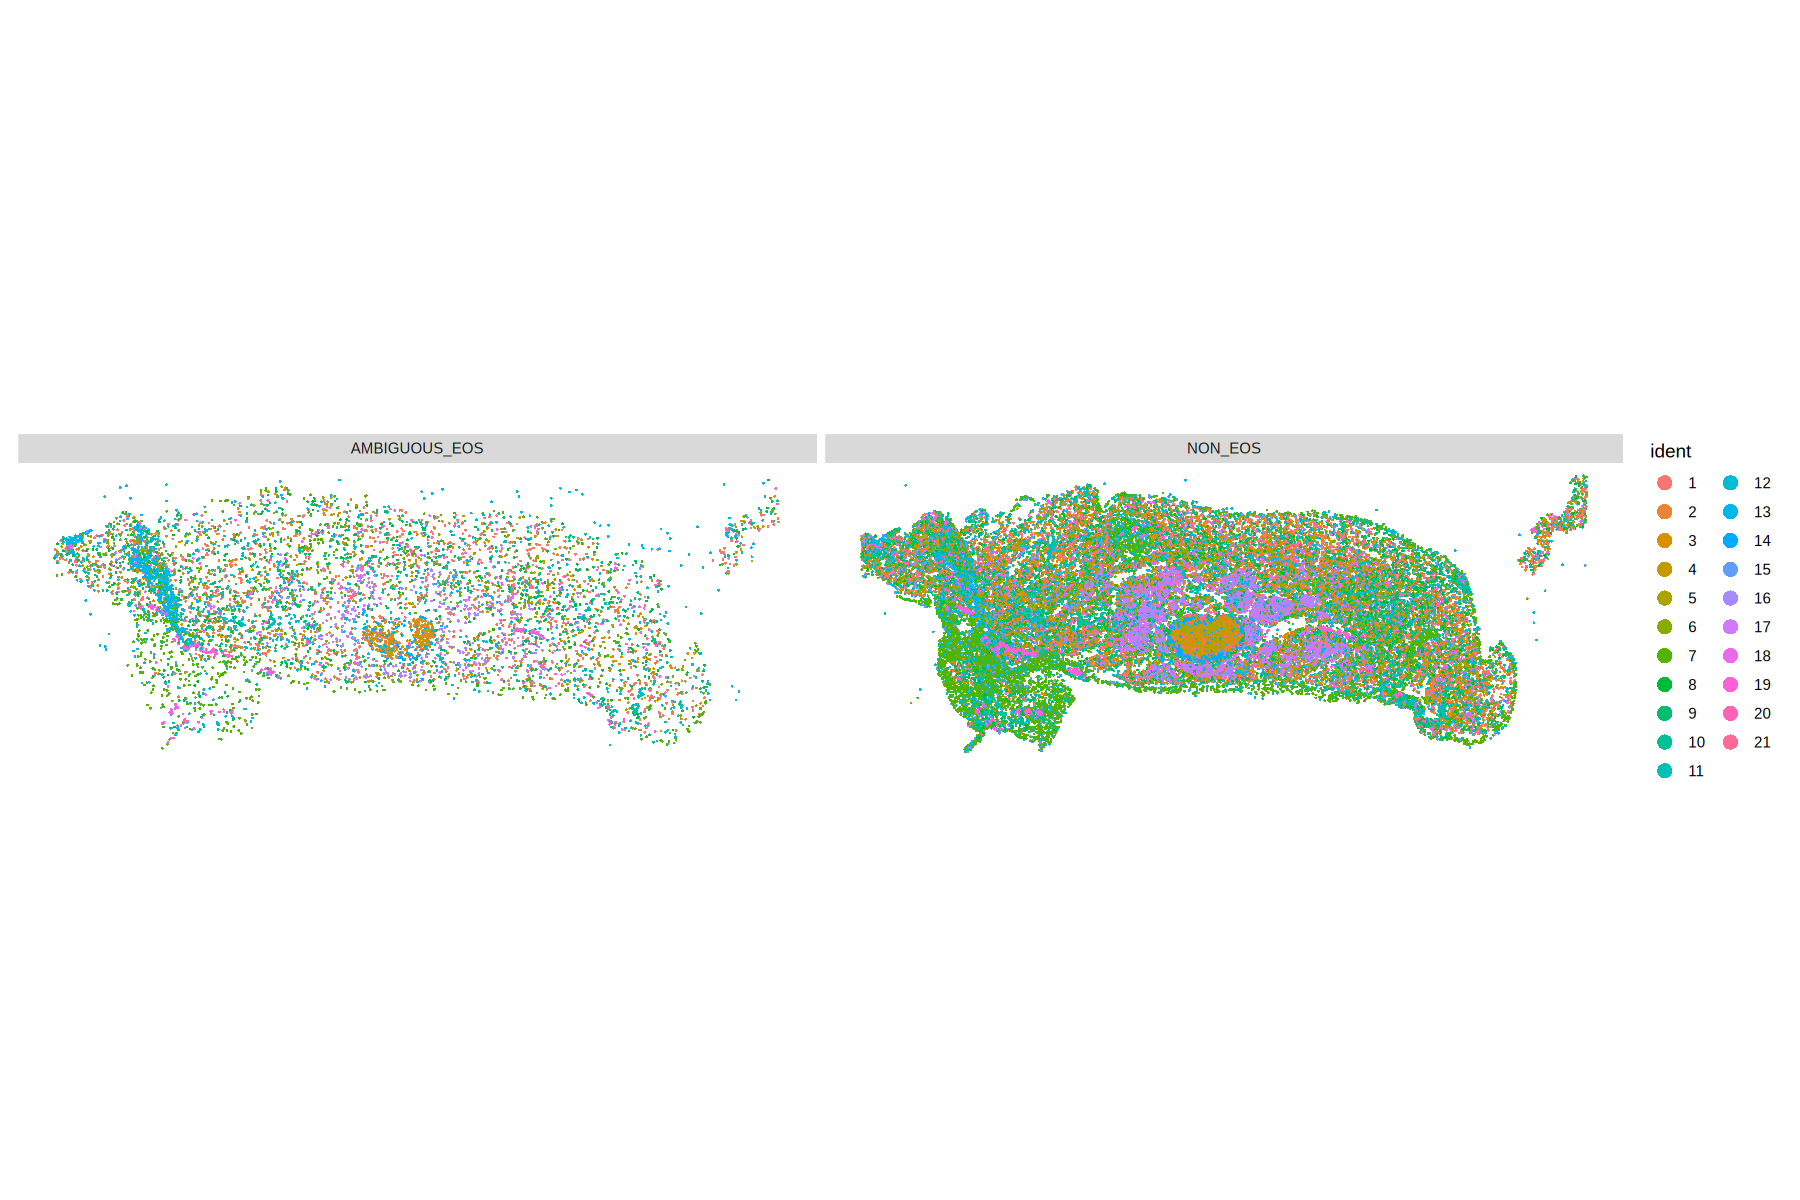

In [88]:
ImageDimPlot(
  region_spatial,
  fov = "fov",
  split.by = "Eos_call",
  flip_xy = FALSE,
  dark.background = FALSE
)

In [89]:
eos_review_cells <- region_spatial@meta.data %>%
  tibble::rownames_to_column("seurat_cell") %>%
  dplyr::filter(
    Eos_call %in%
      c(
        "HIGH_CONFIDENCE_EOS",
        "PROBABLE_EOS",
        "AMBIGUOUS_EOS"
      )
  ) %>%
  dplyr::select(
    seurat_cell,
    cell_id,
    x_centroid,
    y_centroid,
    Eos_call,
    Eos_Wang_subtype_probability_knn,
    Eos_Xenium_score_knn,
    Eos_competitor,
    Eos_vs_competitor_margin,
    Eos_core_n_detected,
    Eos_review_reason
  )

In [90]:
dim(eos_review_cells)

[1] 7720   11